In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import mne
from mne.preprocessing import ICA
import warnings

# Ignorăm warning-urile MNE pentru o consolă mai curată
warnings.filterwarnings('ignore')

# ── 1. Configurare ─────────────────────────────────────────────────────────
INPUT_FOLDER = "recordings_sad"
OUTPUT_FOLDER = "recordings_sad_cleaned"

# Frecvența nativă a OpenBCI cu placa Daisy (16 canale) este 125 Hz.
TARGET_SFREQ = 125.0  

# Pragul pentru detectarea clipitului de către ICA (scade la 2.0 dacă e prea "orb")
EOG_THRESHOLD = 2.5

# Maparea exactă pentru 16 canale standard OpenBCI
CHANNEL_MAPPING = {
    "EEG_1": "Fp1", "EEG_2": "Fp2",
    "EEG_3": "C3",  "EEG_4": "C4",
    "EEG_5": "P7",  "EEG_6": "P8",
    "EEG_7": "O1",  "EEG_8": "O2",
    "EEG_9": "F7",  "EEG_10": "F8",
    "EEG_11": "F3", "EEG_12": "F4",
    "EEG_13": "T7", "EEG_14": "T8",
    "EEG_15": "P3", "EEG_16": "P4"
}

CH_NAMES = list(CHANNEL_MAPPING.keys())
STANDARD_NAMES = list(CHANNEL_MAPPING.values())

def extract_trial_number(filepath: str) -> int:
    """Extrage numărul trial-ului pentru sortare numerică, nu alfabetică."""
    match = re.search(r'trial_(\d+)_', os.path.basename(filepath))
    return int(match.group(1)) if match else 999

# ── 2. Funcția de Procesare pe Fișier ──────────────────────────────────────
def process_file(filepath: str, output_dir: str):
    filename = os.path.basename(filepath)
    print(f"\n[>] Procesez: {filename}")
    
    # -- A. Încărcarea datelor --
    df = pd.read_csv(filepath)
    video_name = df['video'].iloc[0] if 'video' in df.columns else "unknown"
    
    # LSL introduce mici variații de timp. Calculăm media reală a frecvenței de înregistrare.
    duration = df['relative_time'].iloc[-1] - df['relative_time'].iloc[0]
    raw_sfreq = len(df) / duration
    
    # Conversie în Volți pentru MNE
    eeg_data = df[CH_NAMES].values.T * 1e-6 
    info = mne.create_info(ch_names=CH_NAMES, sfreq=raw_sfreq, ch_types='eeg')
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    
    # Aplicăm spațialitatea 3D (Montaj 10-20)
    raw.rename_channels(CHANNEL_MAPPING)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
    
    # -- B. Curățarea Semnalului --
    
    # 1. Resampling la o axă de timp perfectă de 125 Hz (elimină Jitter-ul LSL)
    raw.resample(TARGET_SFREQ, verbose=False)
    
    # 2. Filtrare
    # Eliminăm frecvențele sub 1Hz (transpirație, mișcare lentă a capului) și peste 40Hz (mușchi)
    raw.filter(l_freq=1.0, h_freq=45.0, verbose=False)
    # Eliminăm bruiajul rețelei electrice (50 Hz în Europa/România)
    raw.notch_filter(freqs=50.0, verbose=False)
    
    # 3. CAR (Common Average Reference) - scade zgomotul global
    raw.set_eeg_reference('average', projection=False, verbose=False)
    
    # -- C. Eliminarea Clipitului prin ICA --
    ica = ICA(n_components=15, random_state=42, max_iter=1000, method='fastica')
    ica.fit(raw, verbose=False)
    
    bads_ica = []
    # Folosim senzorii de pe frunte (Fp1, Fp2) ca detectoare de clipit
    for frontal_ch in ["Fp1", "Fp2"]:
        eog_indices, _ = ica.find_bads_eog(
            raw, 
            ch_name=frontal_ch, 
            threshold=EOG_THRESHOLD, 
            verbose=False
        )
        bads_ica.extend(eog_indices)
            
    ica.exclude = list(set(bads_ica))
    print(f"    Componente clipit șterse: {ica.exclude if ica.exclude else 'Niciuna'}")
    
    ica.apply(raw, verbose=False)
    
    # -- D. Exportul Datelor Curate --
    # Readucem datele la microVolți pentru a fi ușor de interpretat de tine ulterior
    cleaned_eeg_data = raw.get_data().T * 1e6 
    
    # Recreăm axa de timp perfect sincronizată (1/125 secunde între eșantioane)
    new_n_samples = cleaned_eeg_data.shape[0]
    new_time = np.arange(new_n_samples) / TARGET_SFREQ
    
    # Construim noul CSV
    df_cleaned = pd.DataFrame(cleaned_eeg_data, columns=STANDARD_NAMES)
    df_cleaned.insert(0, 'relative_time', new_time)
    df_cleaned['video'] = video_name
    
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"clean_{filename}")
    df_cleaned.to_csv(out_path, index=False)
    print(f"  ✓ Salvat: clean_{filename}")

# ── 3. Execuția ────────────────────────────────────────────────────────────
def main():
    if not os.path.exists(INPUT_FOLDER):
        print(f"Eroare: Nu am găsit folderul '{INPUT_FOLDER}'.")
        return
        
    csv_files = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))
    if not csv_files:
        print("Nu există fișiere de procesat.")
        return
        
    csv_files = sorted(csv_files, key=extract_trial_number)
        
    for filepath in csv_files:
        try:
            process_file(filepath, OUTPUT_FOLDER)
        except Exception as e:
            print(f"  ⚠ Eroare neașteptată la {os.path.basename(filepath)}: {e}")
            
    print(f"\n✓ Datele OpenBCI au fost curățate cu succes. Le găsești în folderul: {OUTPUT_FOLDER}")

if __name__ == "__main__":
    main()


[>] Procesez: trial_1_True_Love_Waits.csv
    Componente clipit șterse: [0, 3]
  ✓ Salvat: clean_trial_1_True_Love_Waits.csv

[>] Procesez: trial_2_Dearly_Departed.csv
    Componente clipit șterse: [1, 6]
  ✓ Salvat: clean_trial_2_Dearly_Departed.csv

[>] Procesez: trial_3_Fix_You.csv
    Componente clipit șterse: [0, 6]
  ✓ Salvat: clean_trial_3_Fix_You.csv

[>] Procesez: trial_4_O.csv
    Componente clipit șterse: [0, 4, 5]
  ✓ Salvat: clean_trial_4_O.csv

[>] Procesez: trial_5_Happens_to_the_Heart.csv
    Componente clipit șterse: [0]
  ✓ Salvat: clean_trial_5_Happens_to_the_Heart.csv

[>] Procesez: trial_6_Dawn_Chorus.csv
    Componente clipit șterse: [0, 1, 3]
  ✓ Salvat: clean_trial_6_Dawn_Chorus.csv

[>] Procesez: trial_7_Nude.csv
    Componente clipit șterse: [0]
  ✓ Salvat: clean_trial_7_Nude.csv

[>] Procesez: trial_8_And_I_Love_Her.csv
    Componente clipit șterse: [9, 3]
  ✓ Salvat: clean_trial_8_And_I_Love_Her.csv

[>] Procesez: trial_9_Siempre_me_quedará.csv
    Componen

Extrag trăsăturile. Închide fereastra graficului pentru a trece la următorul trial.


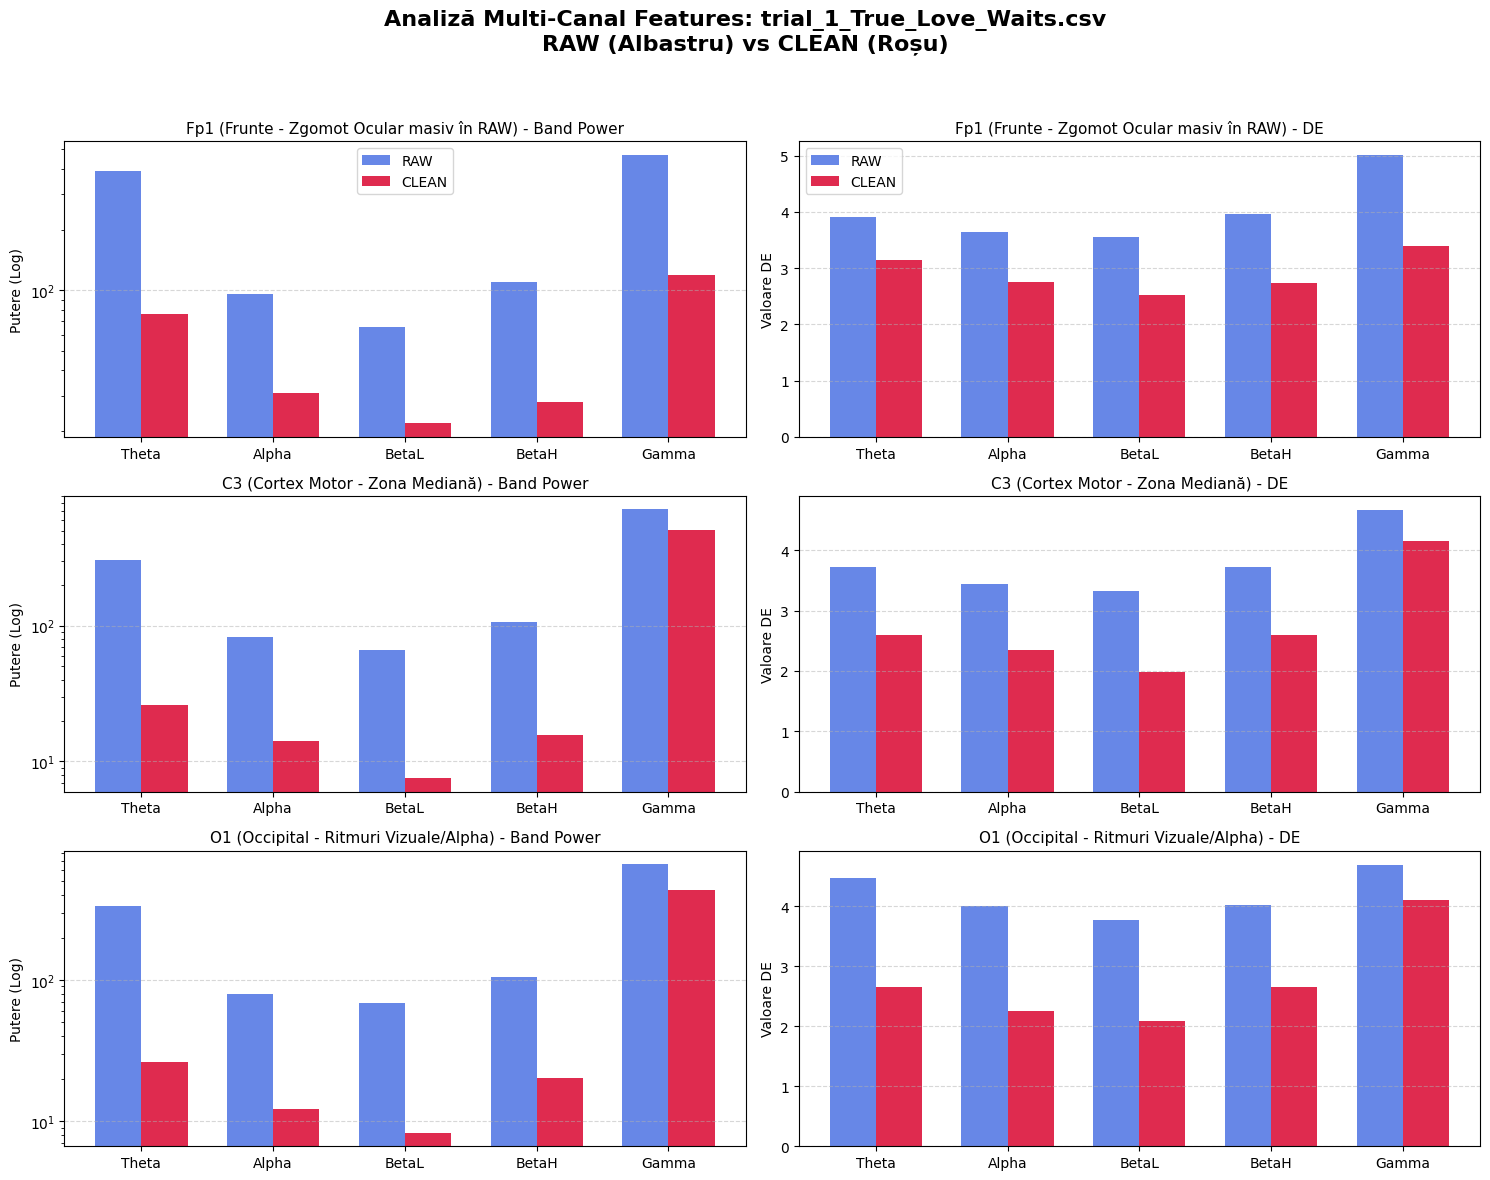

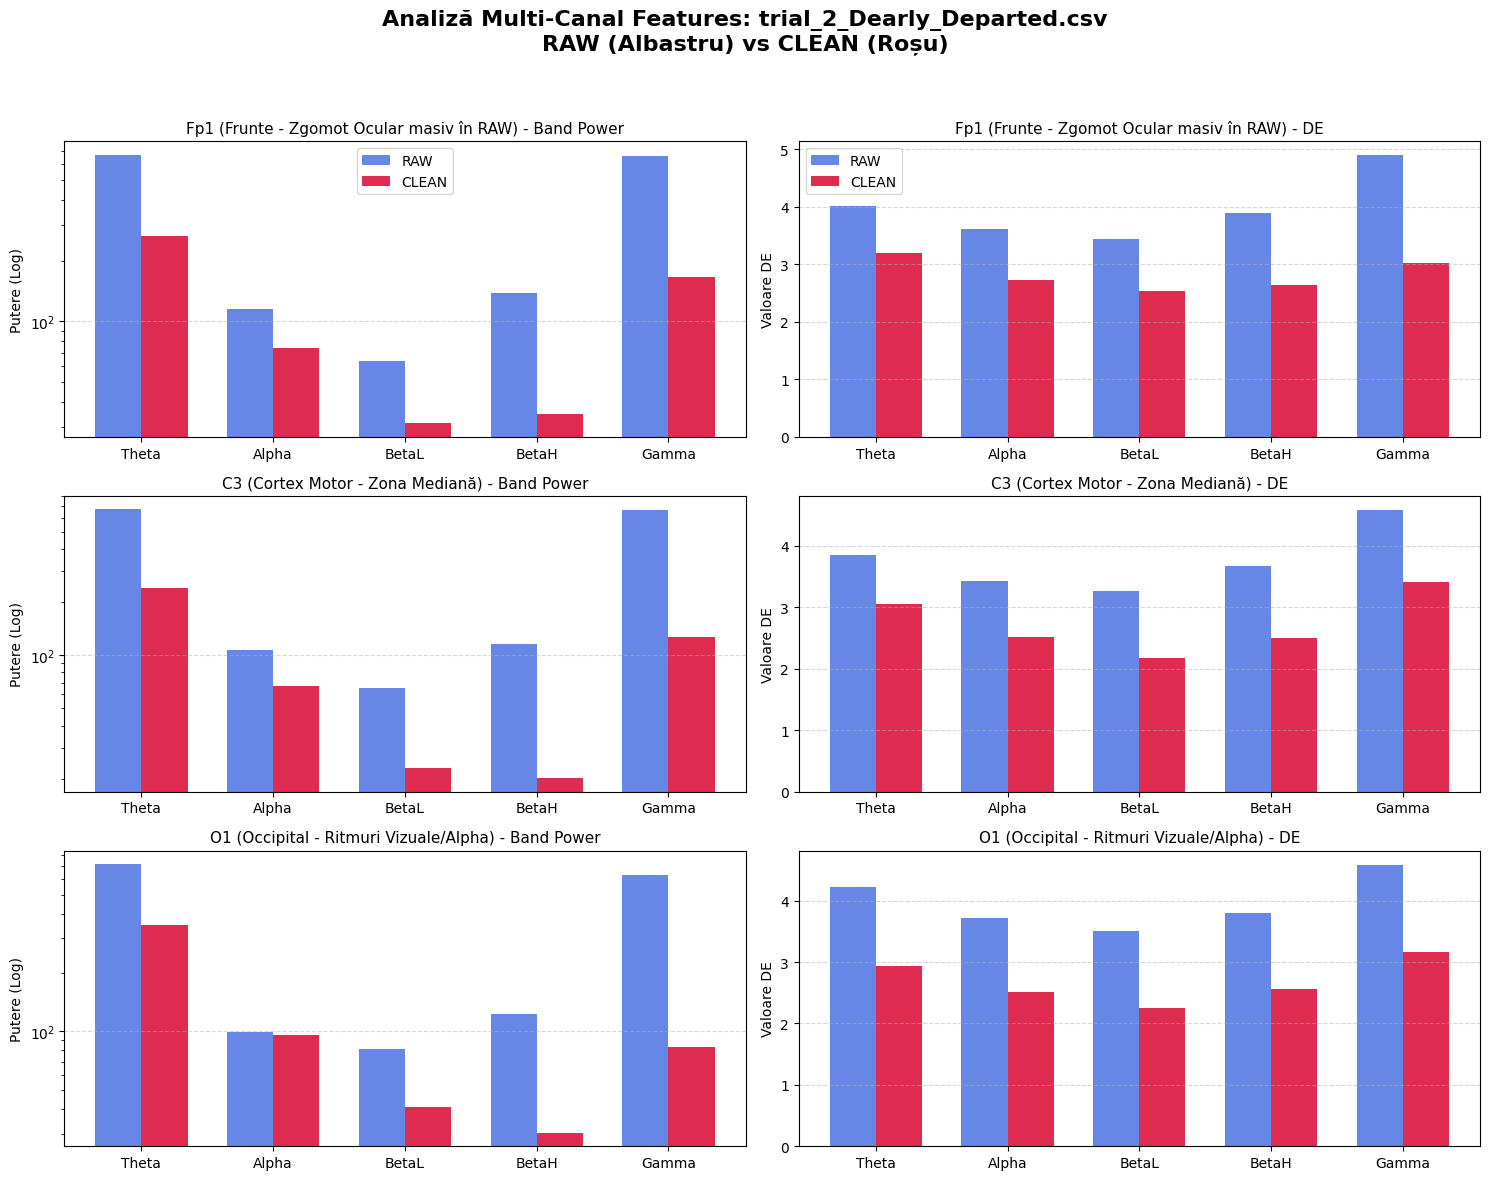

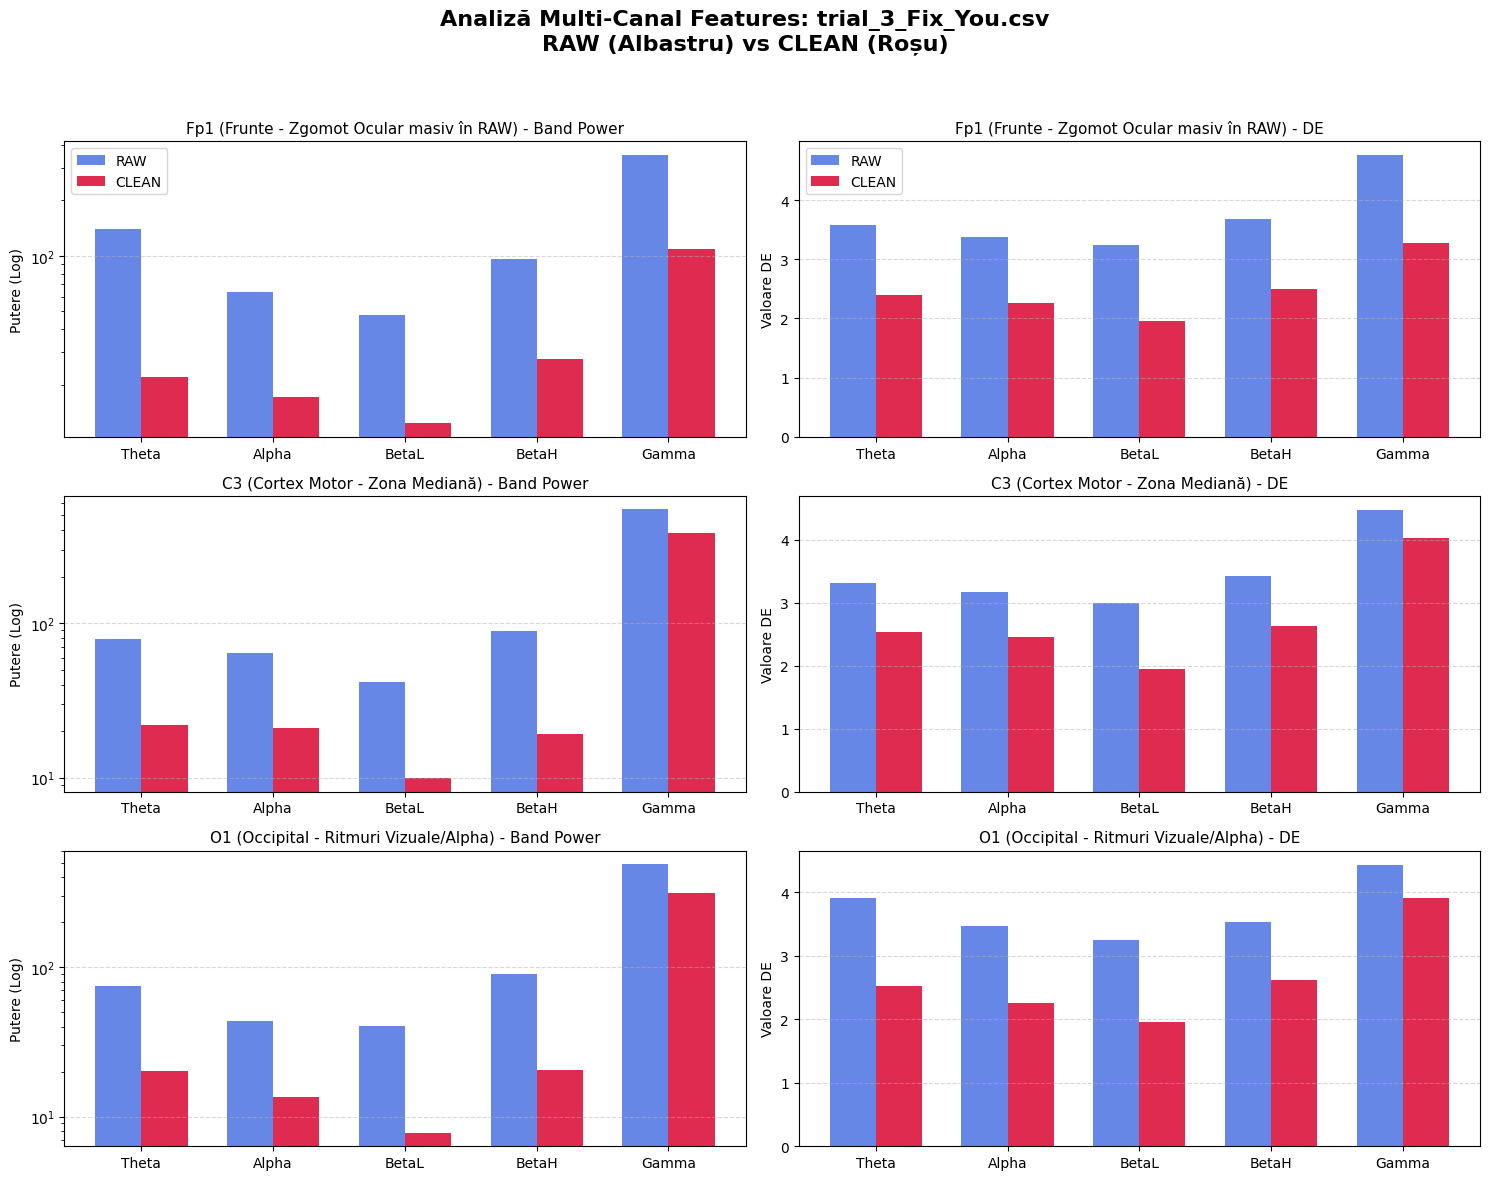

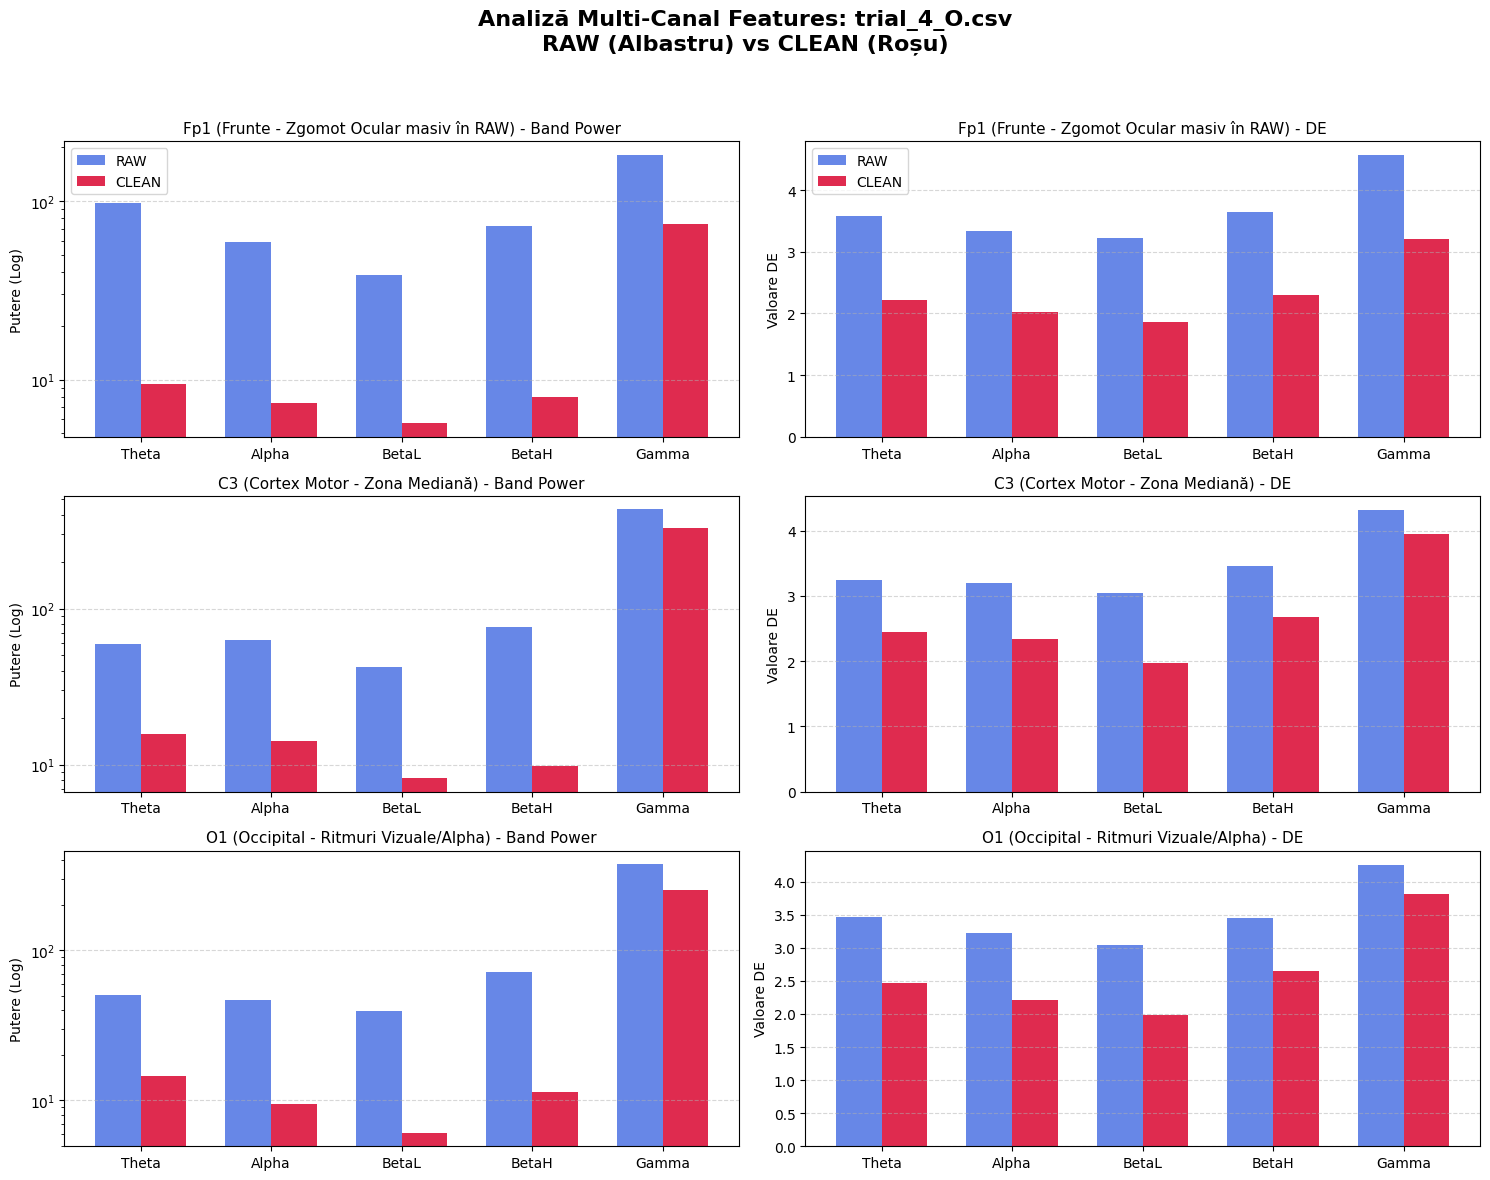

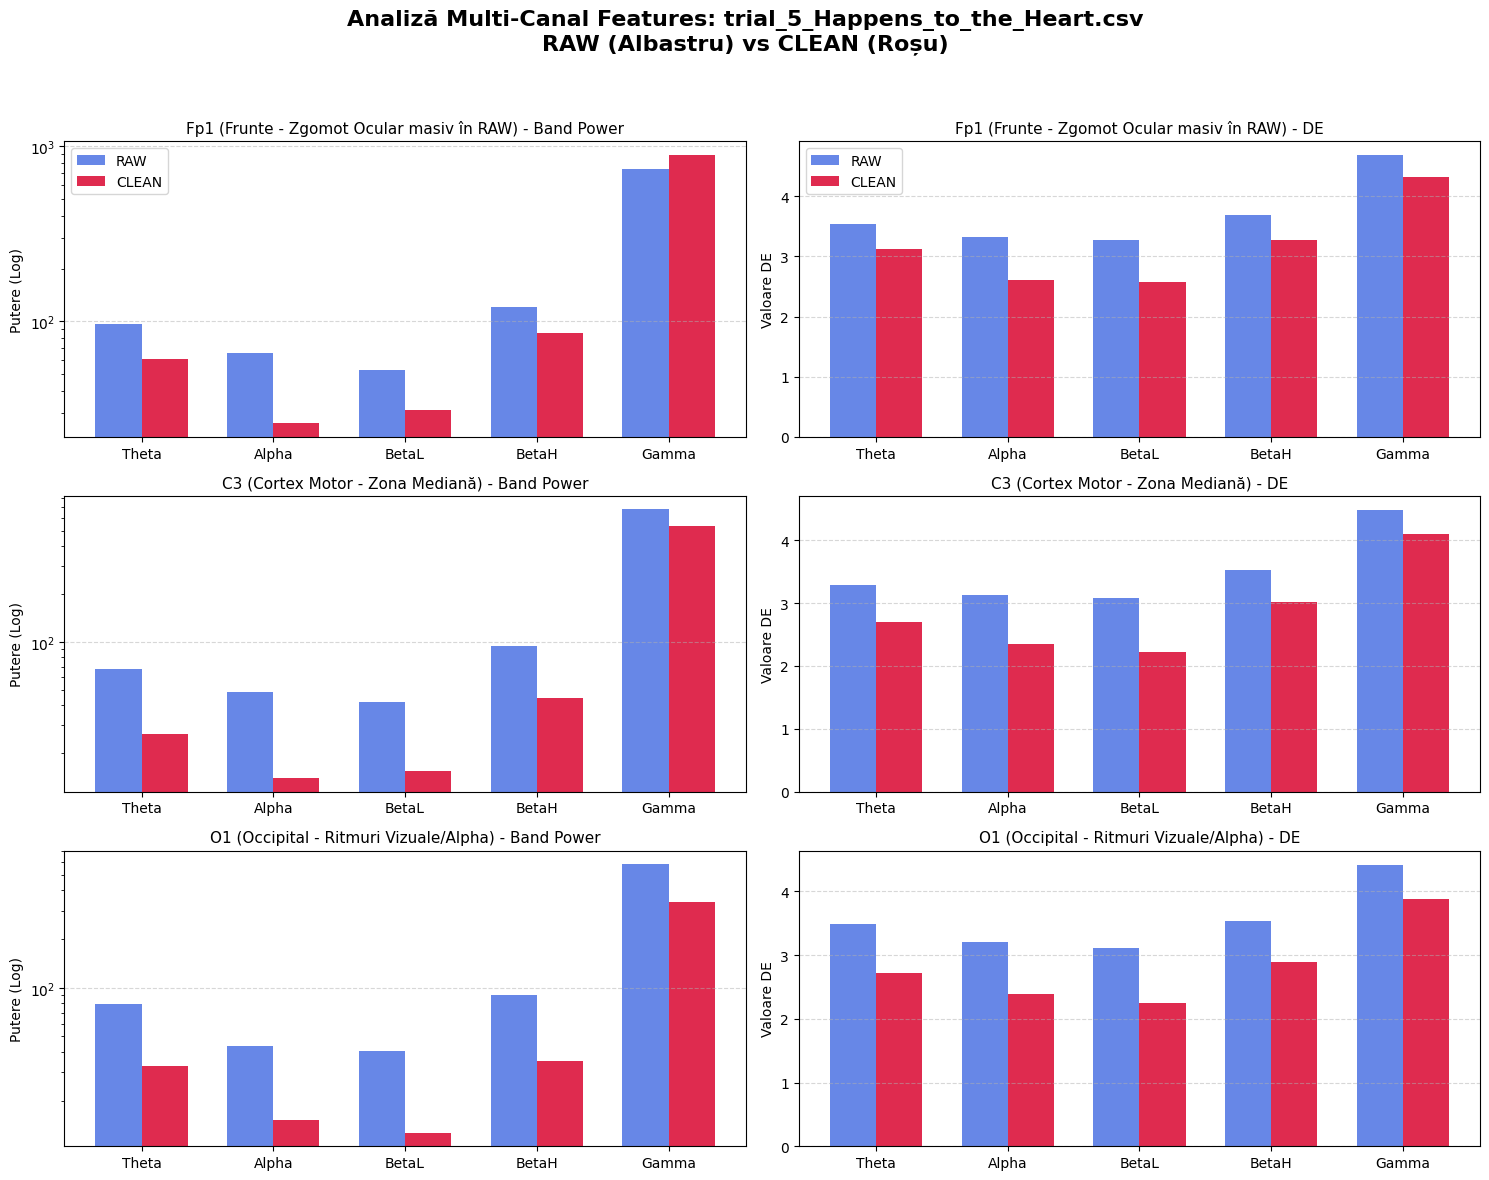

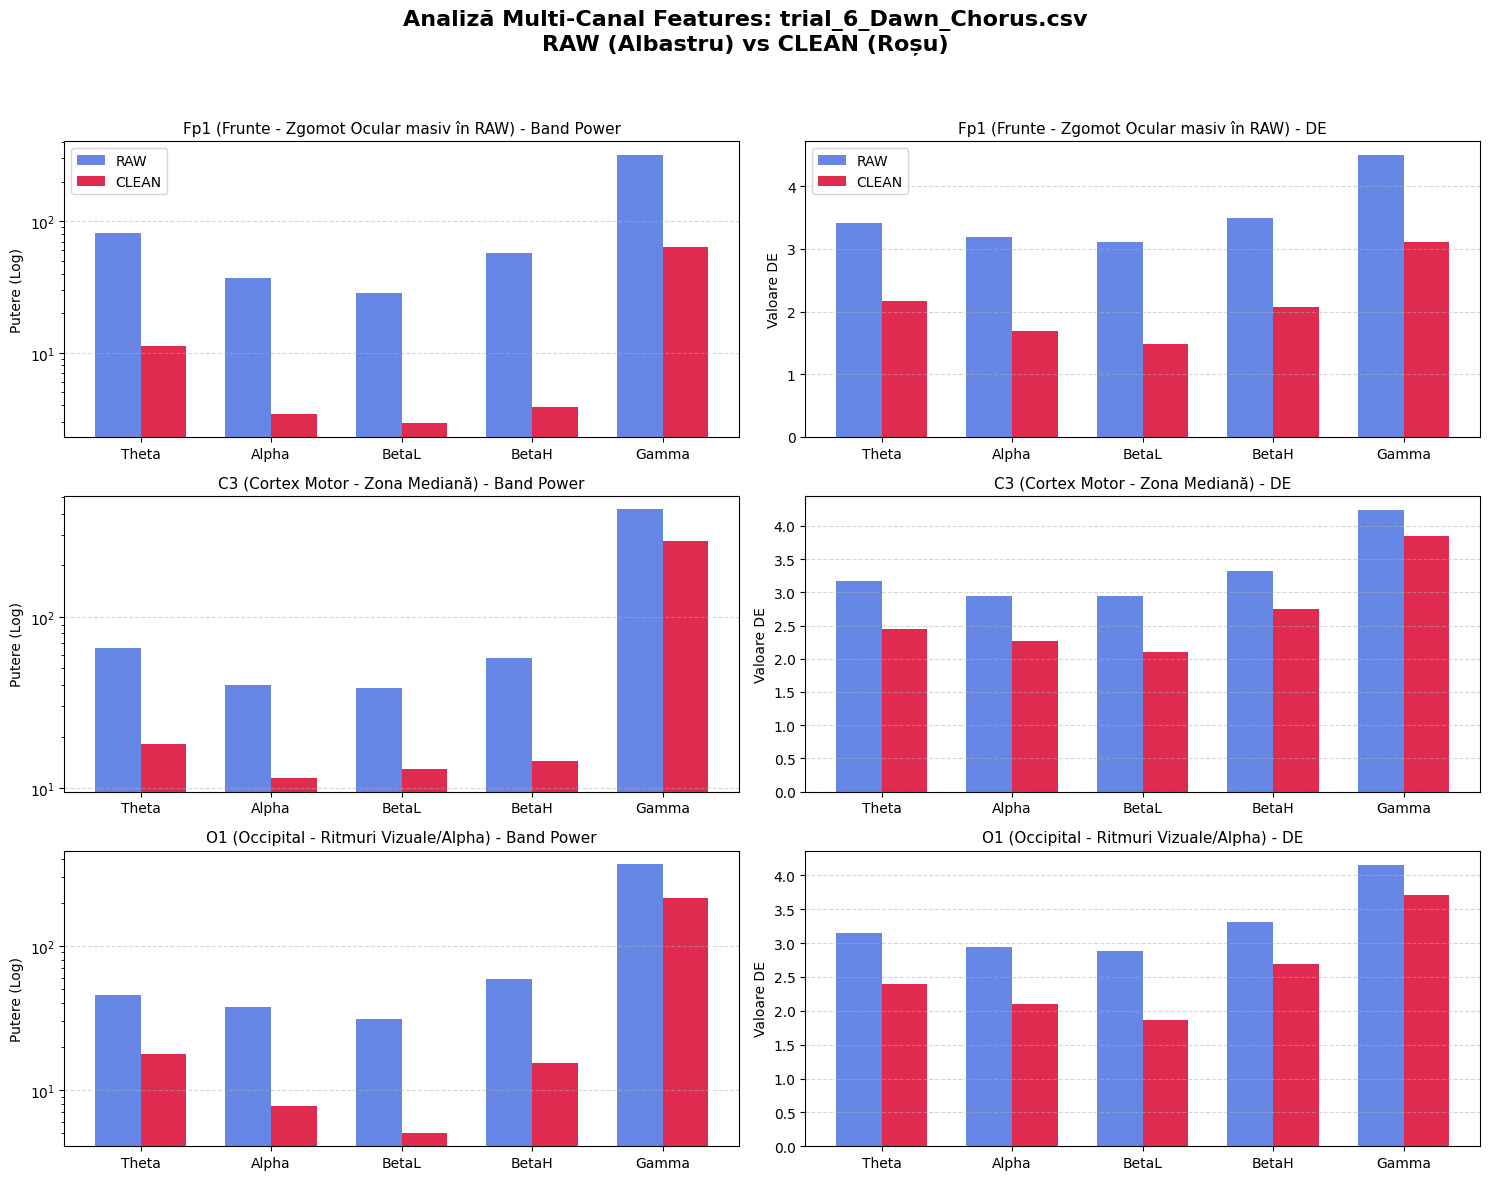

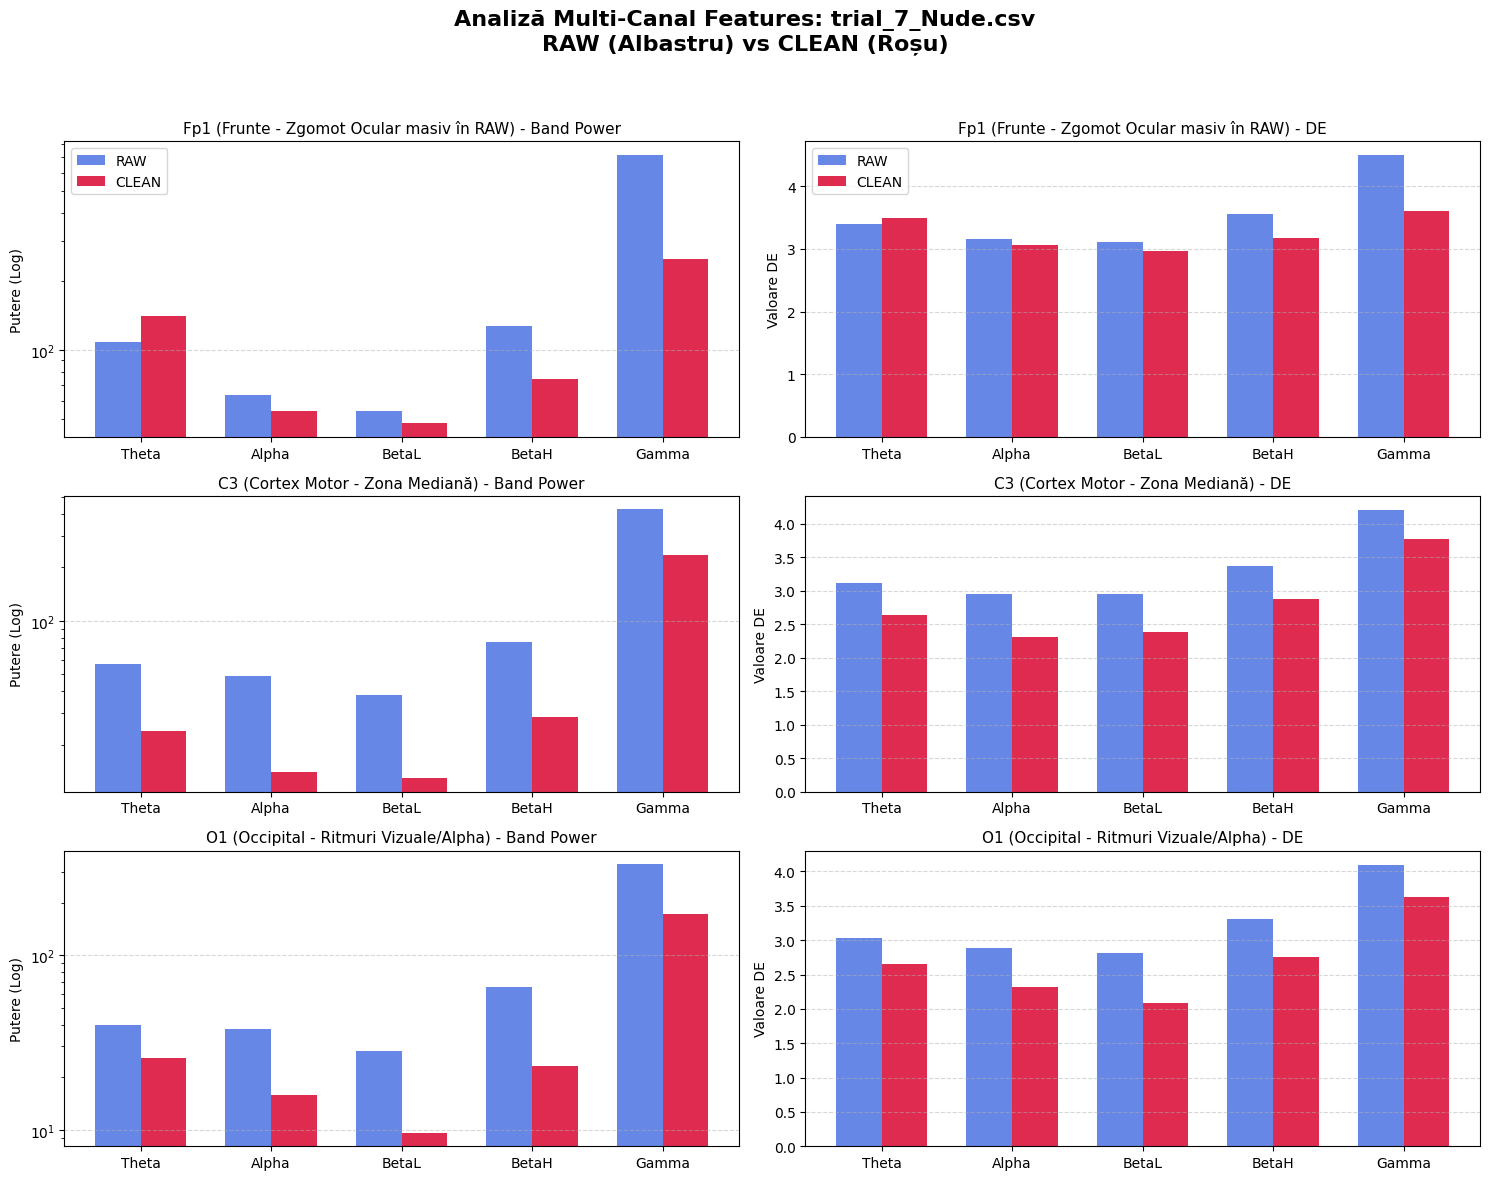

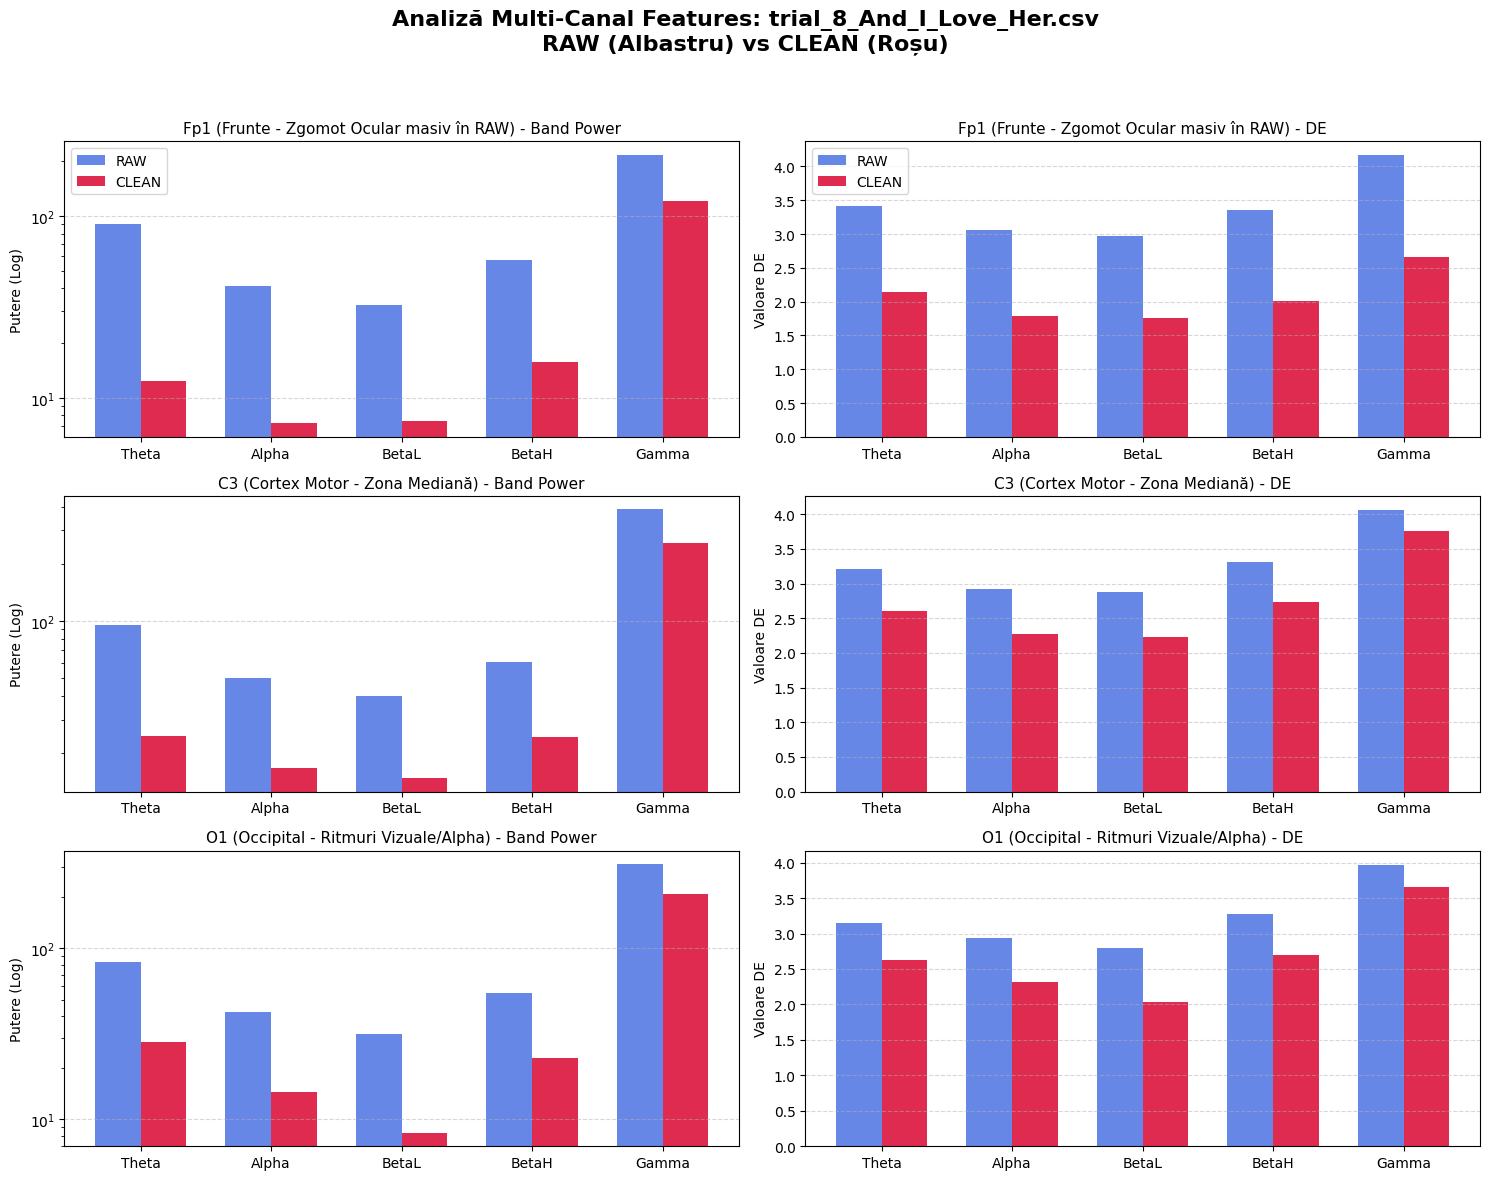

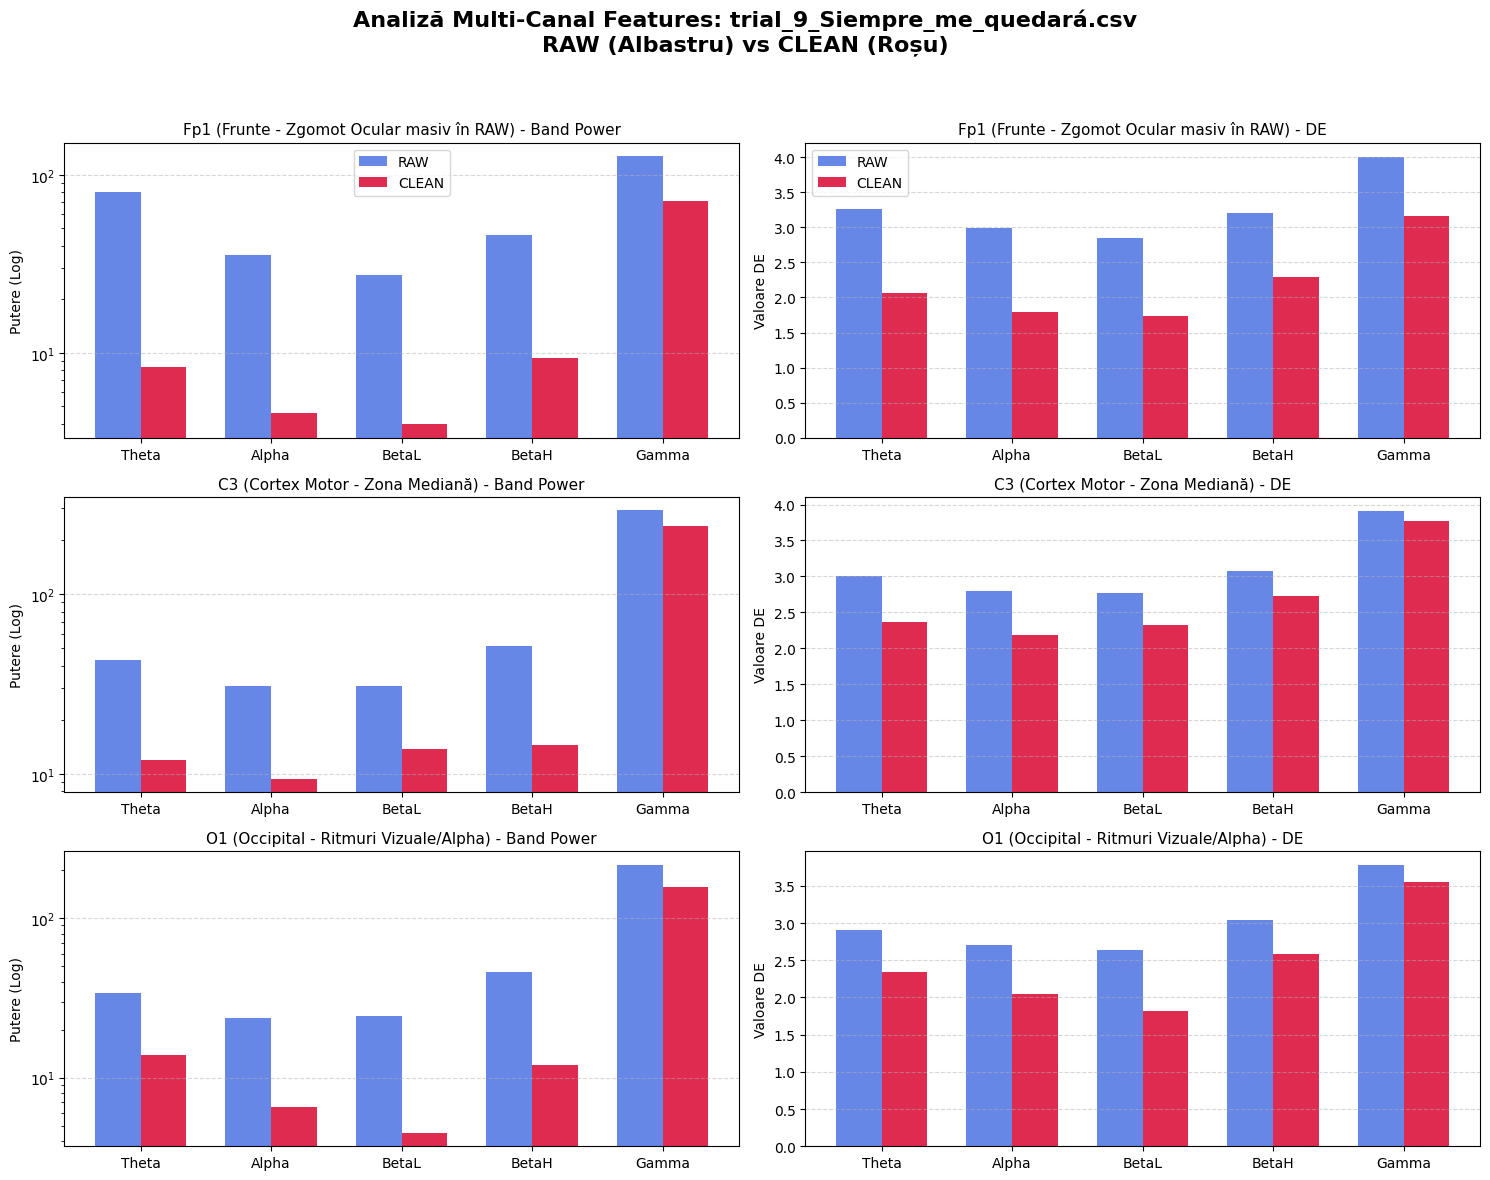

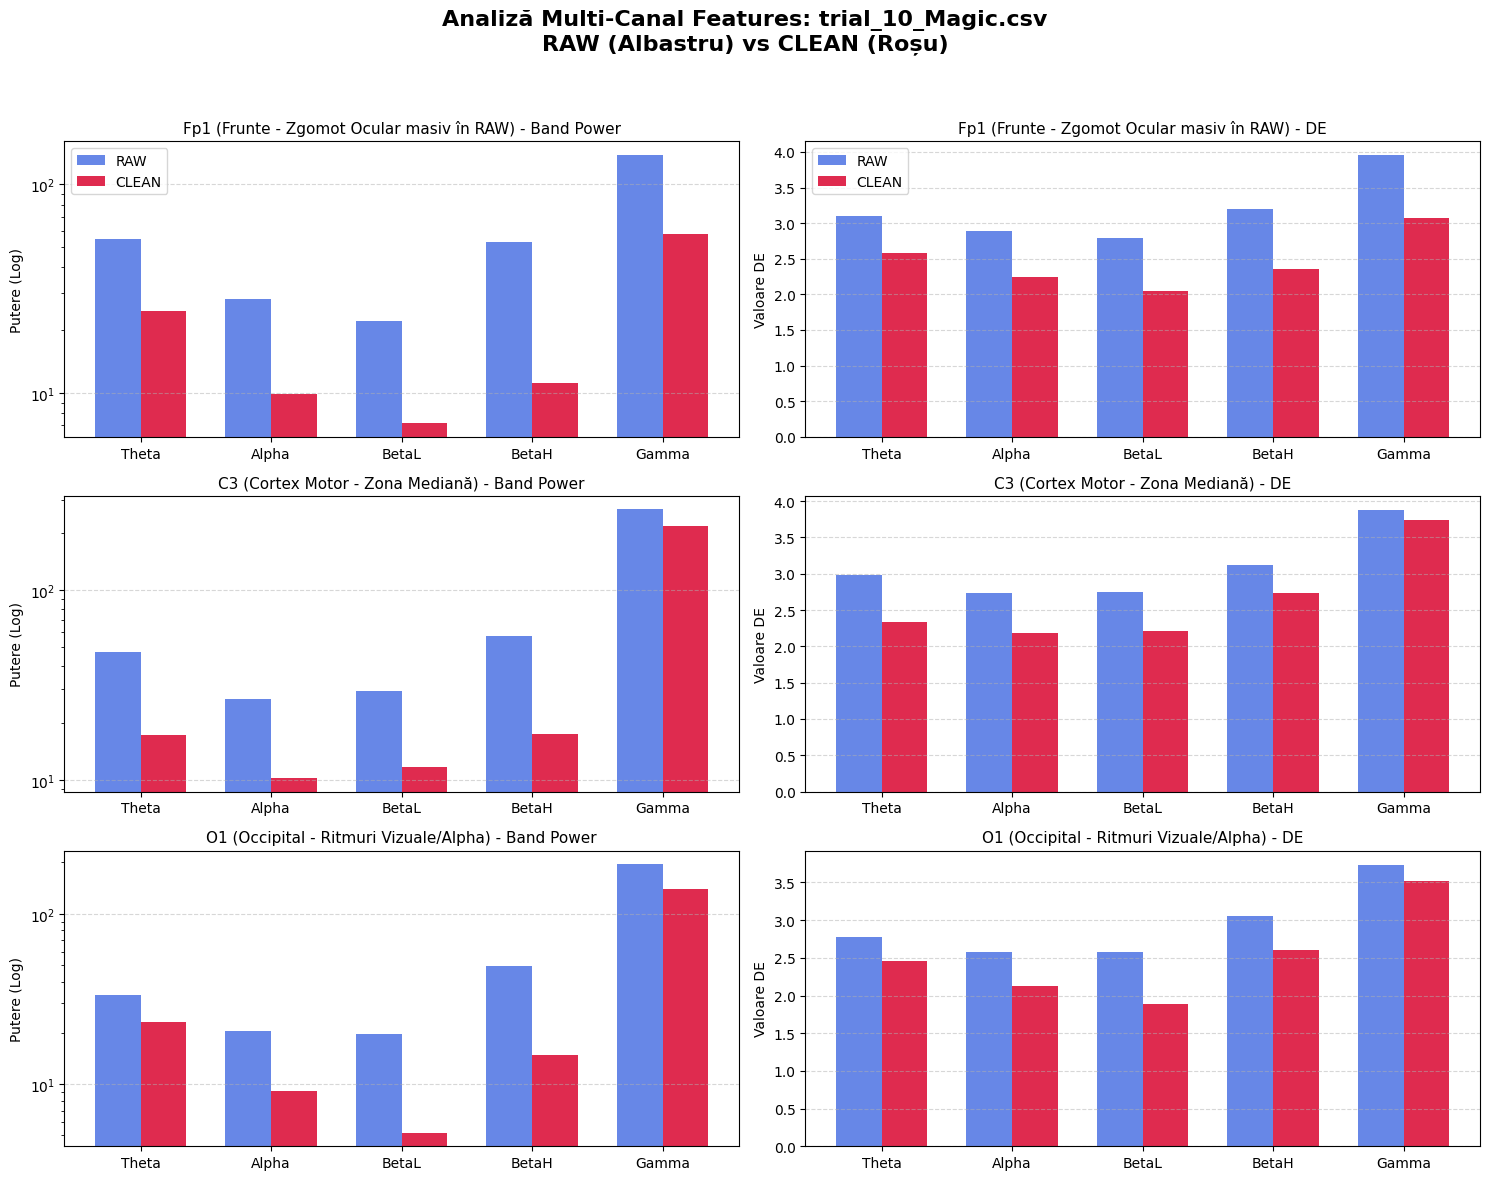

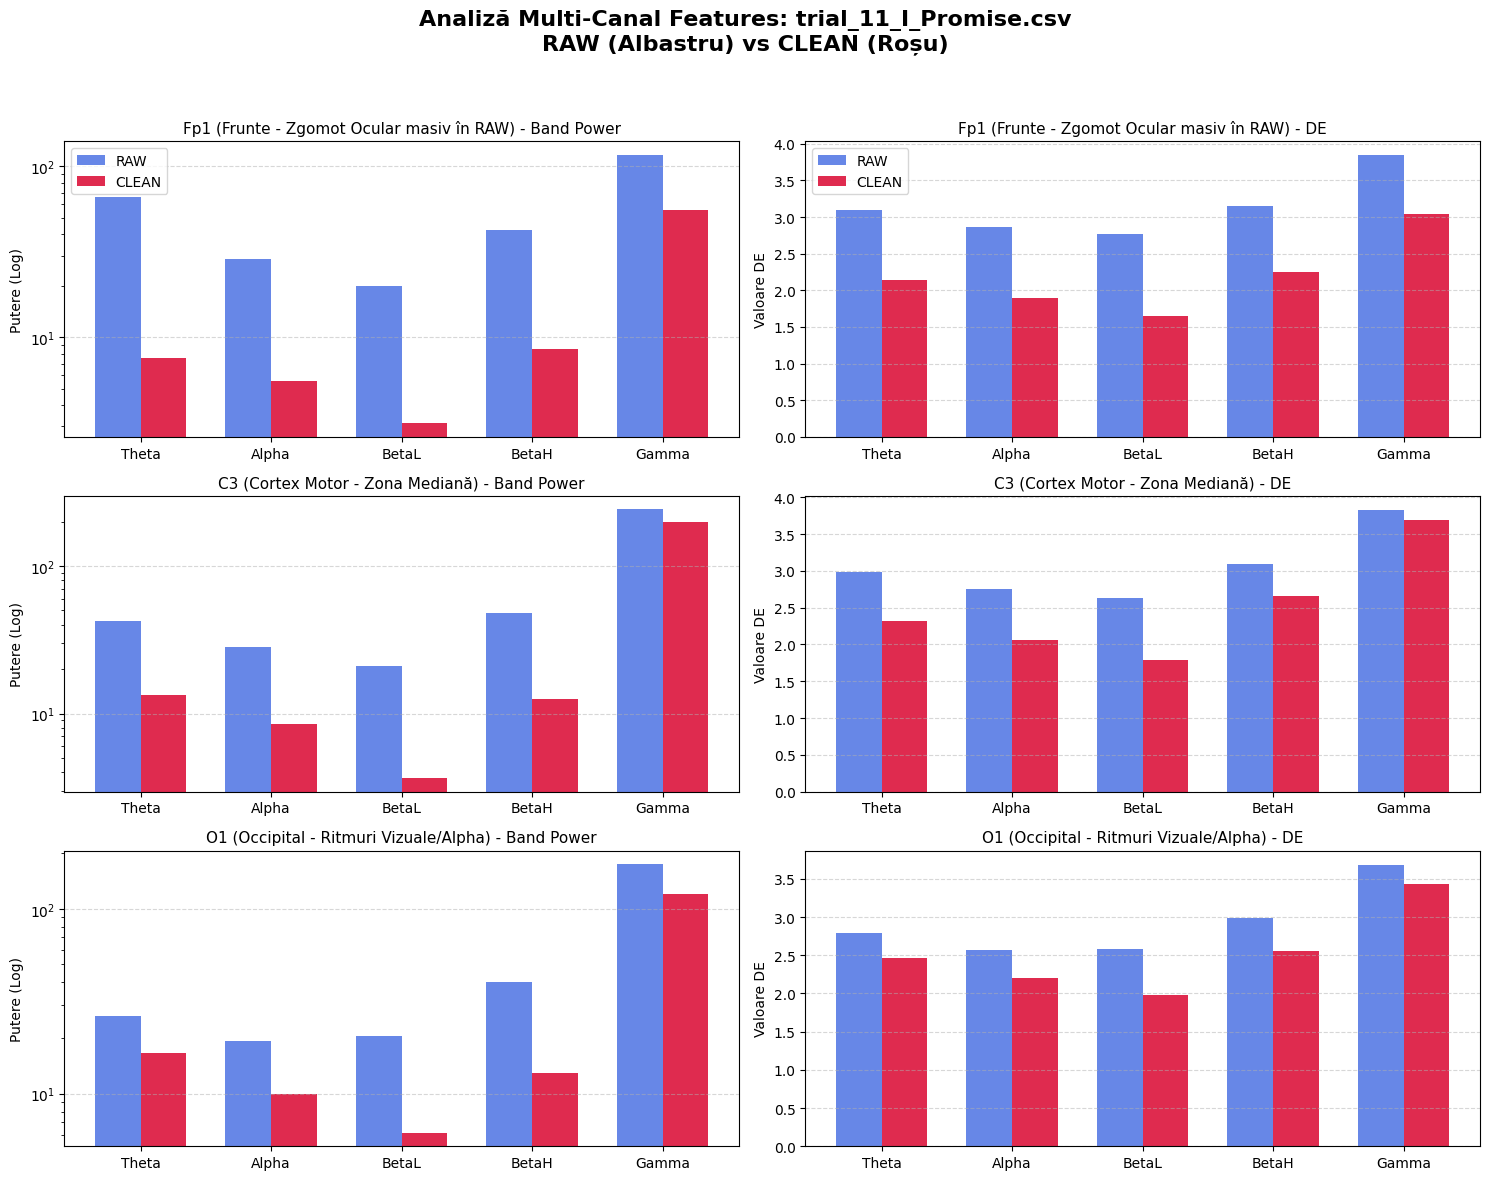

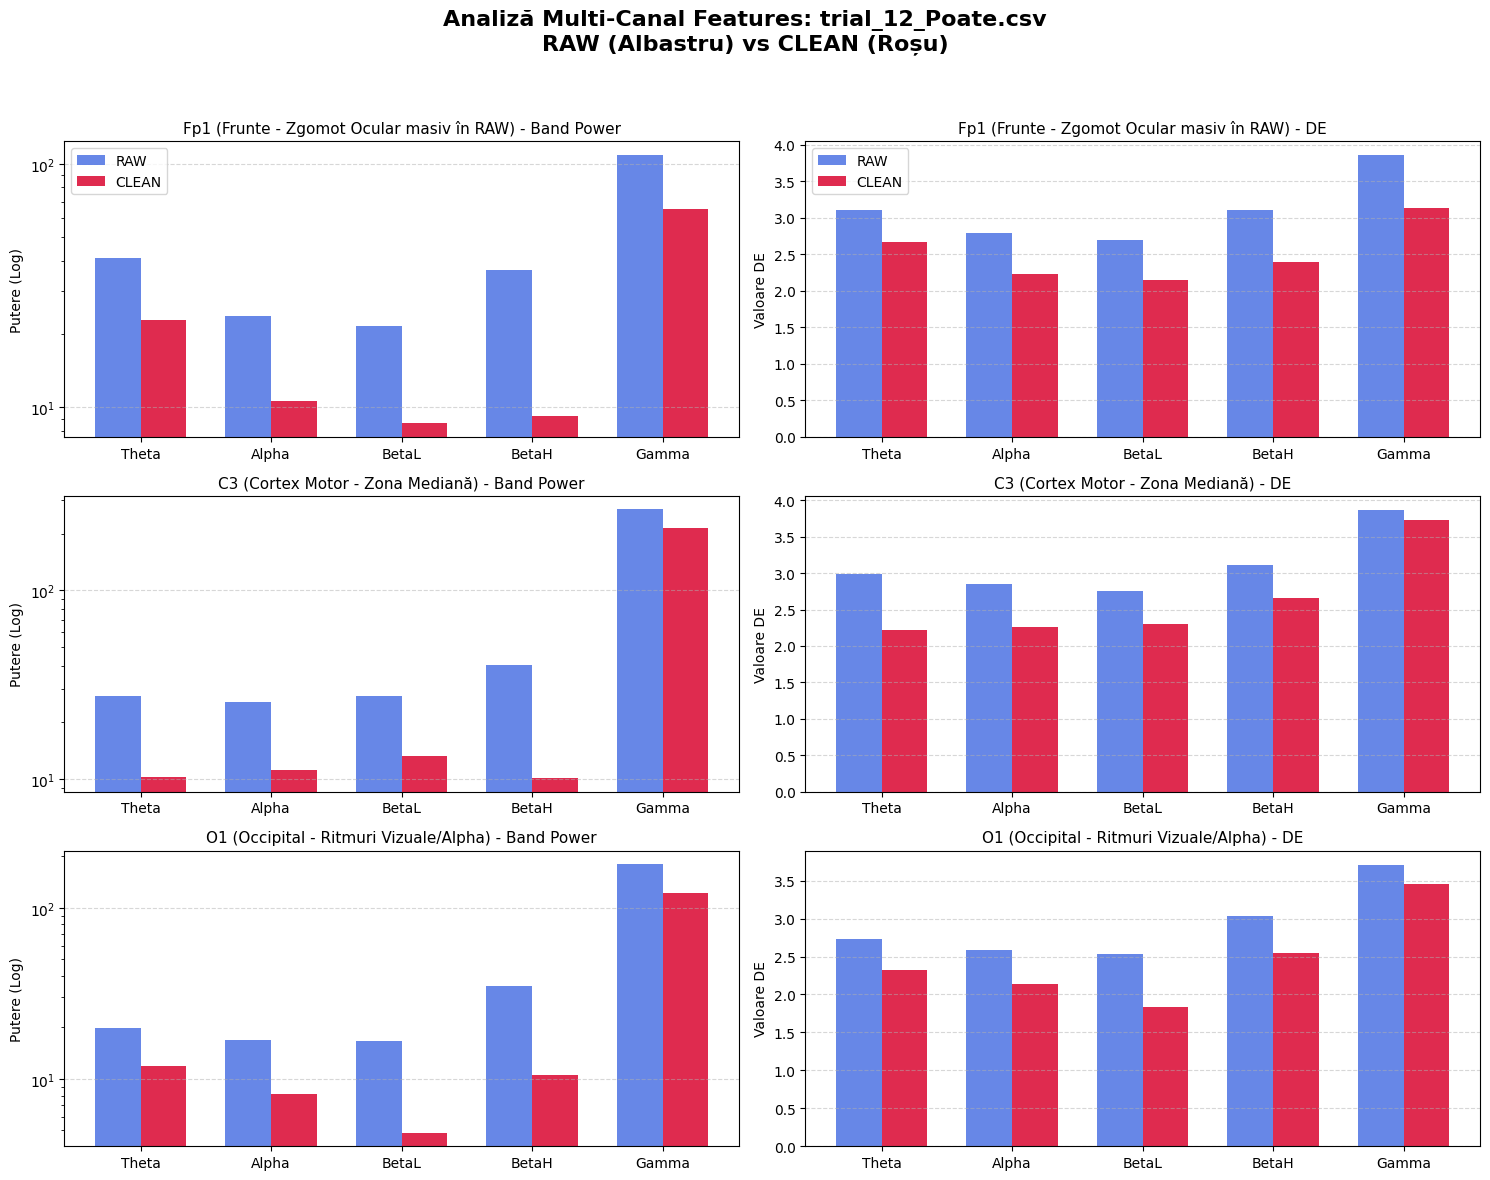

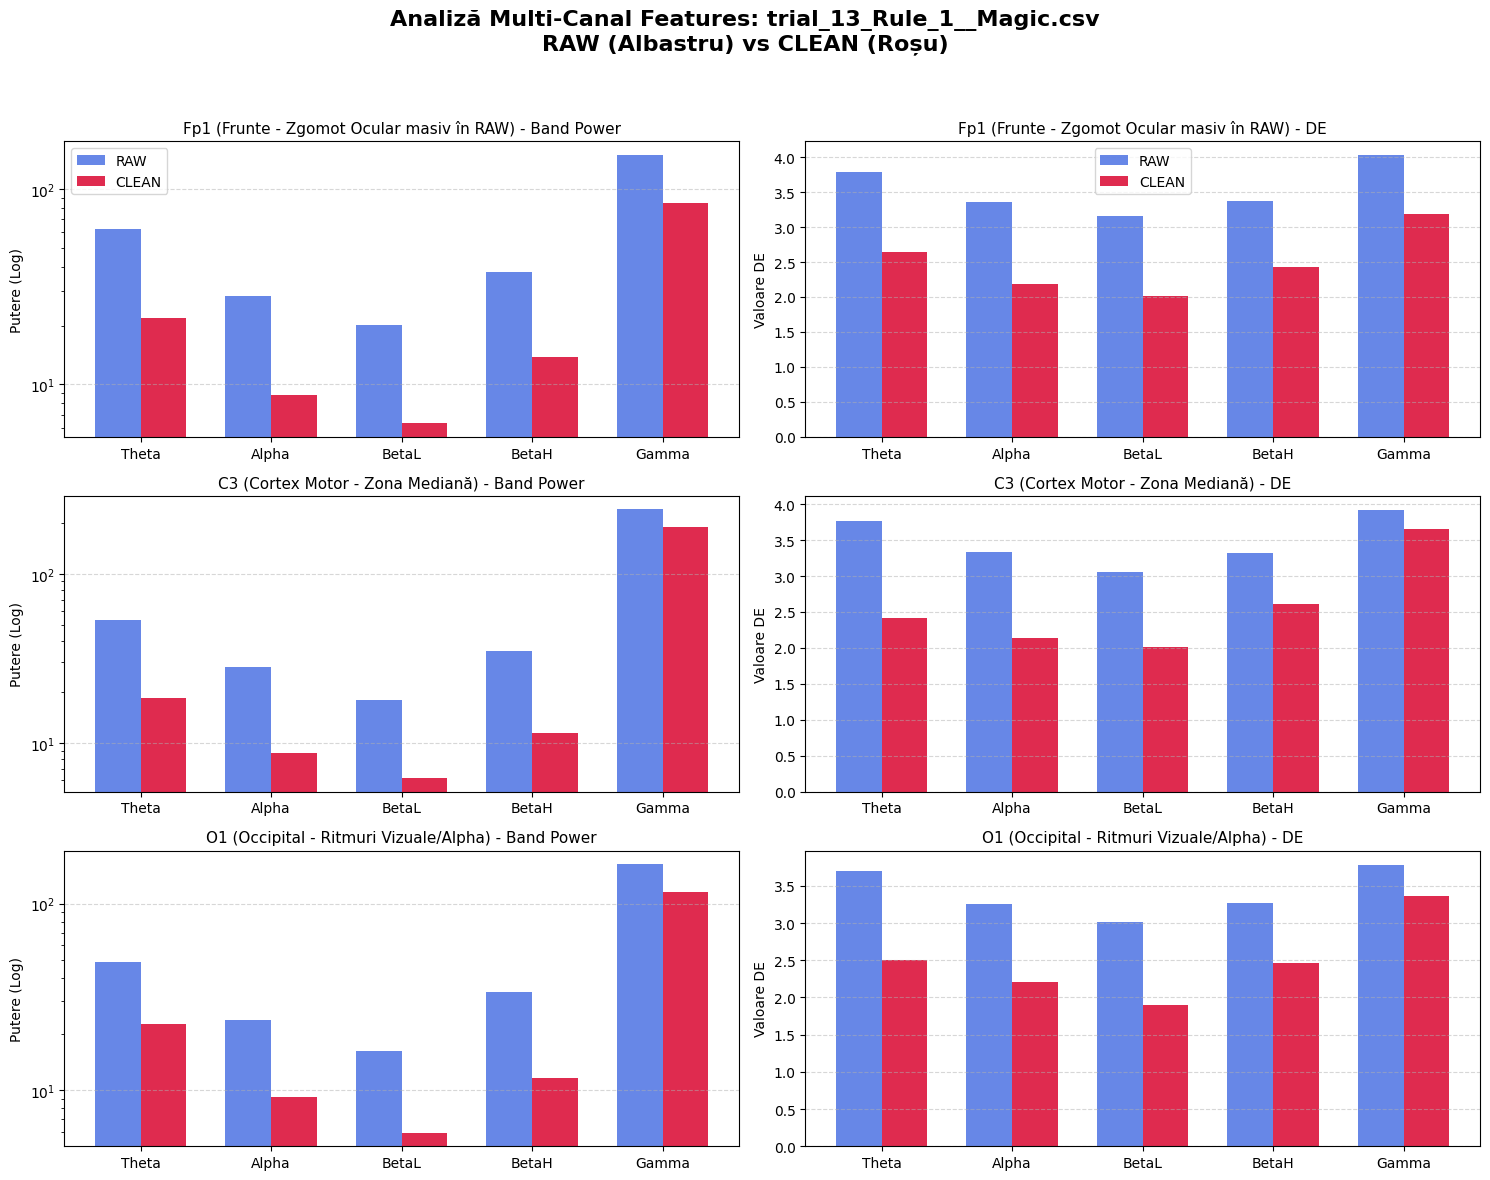

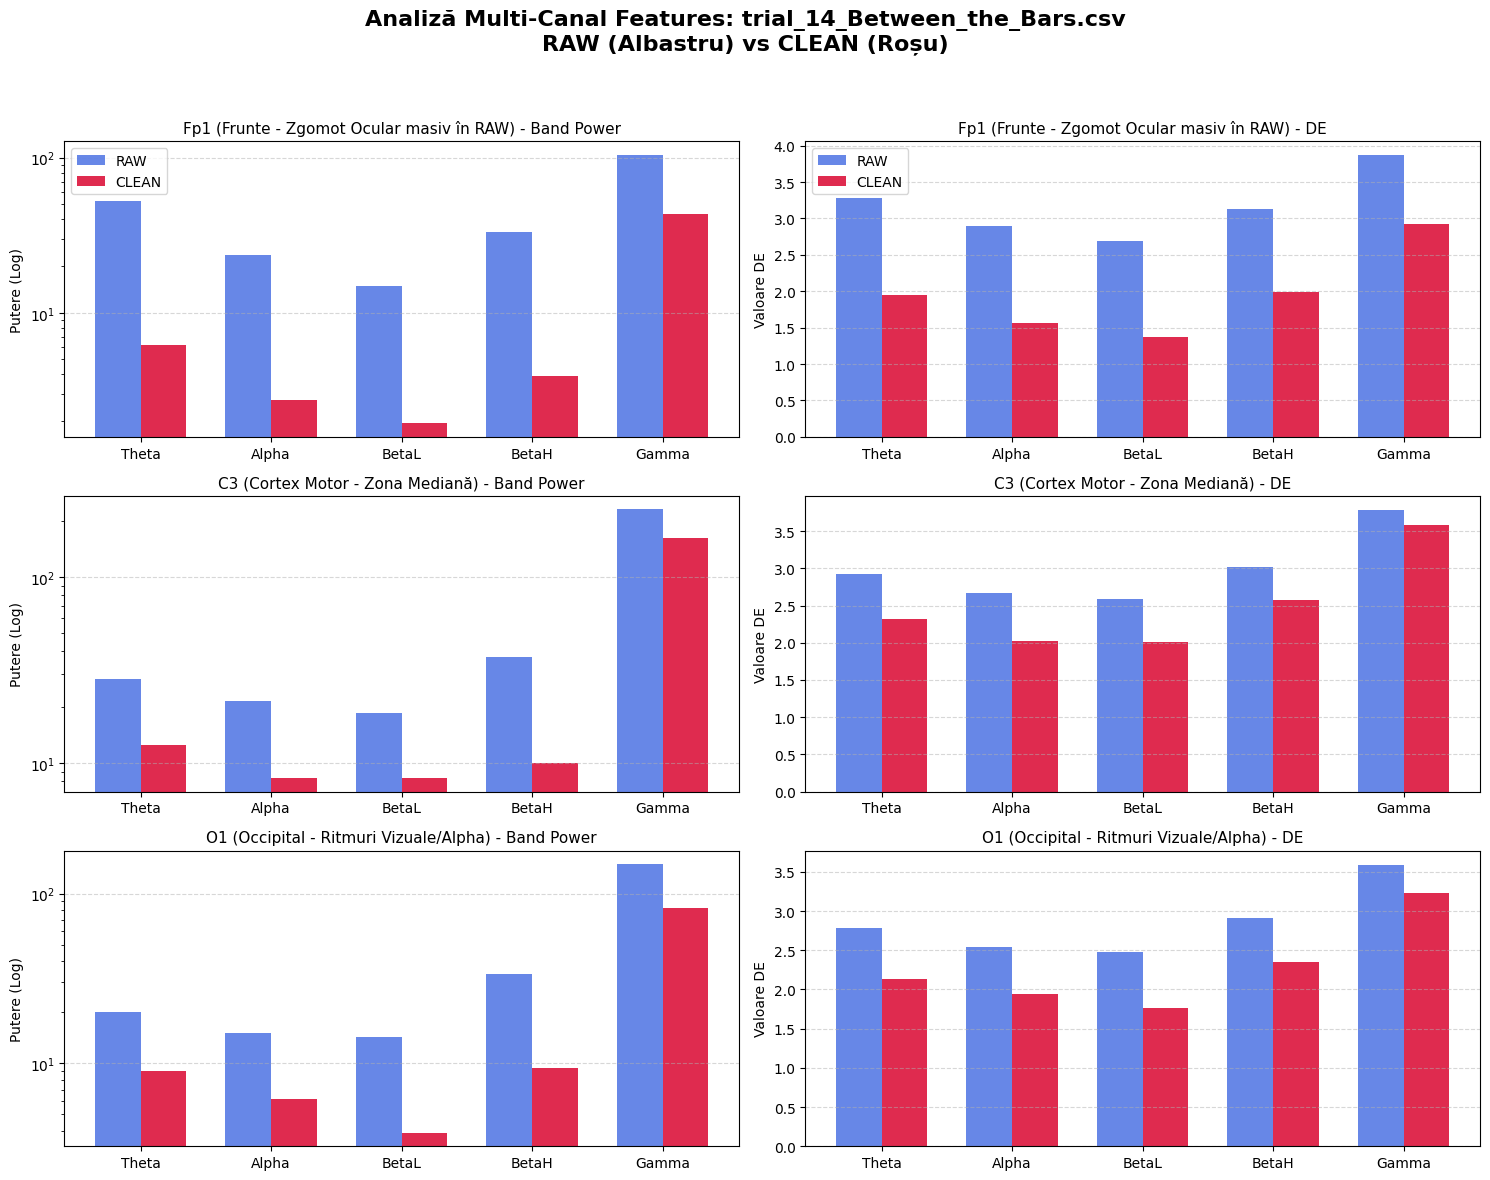

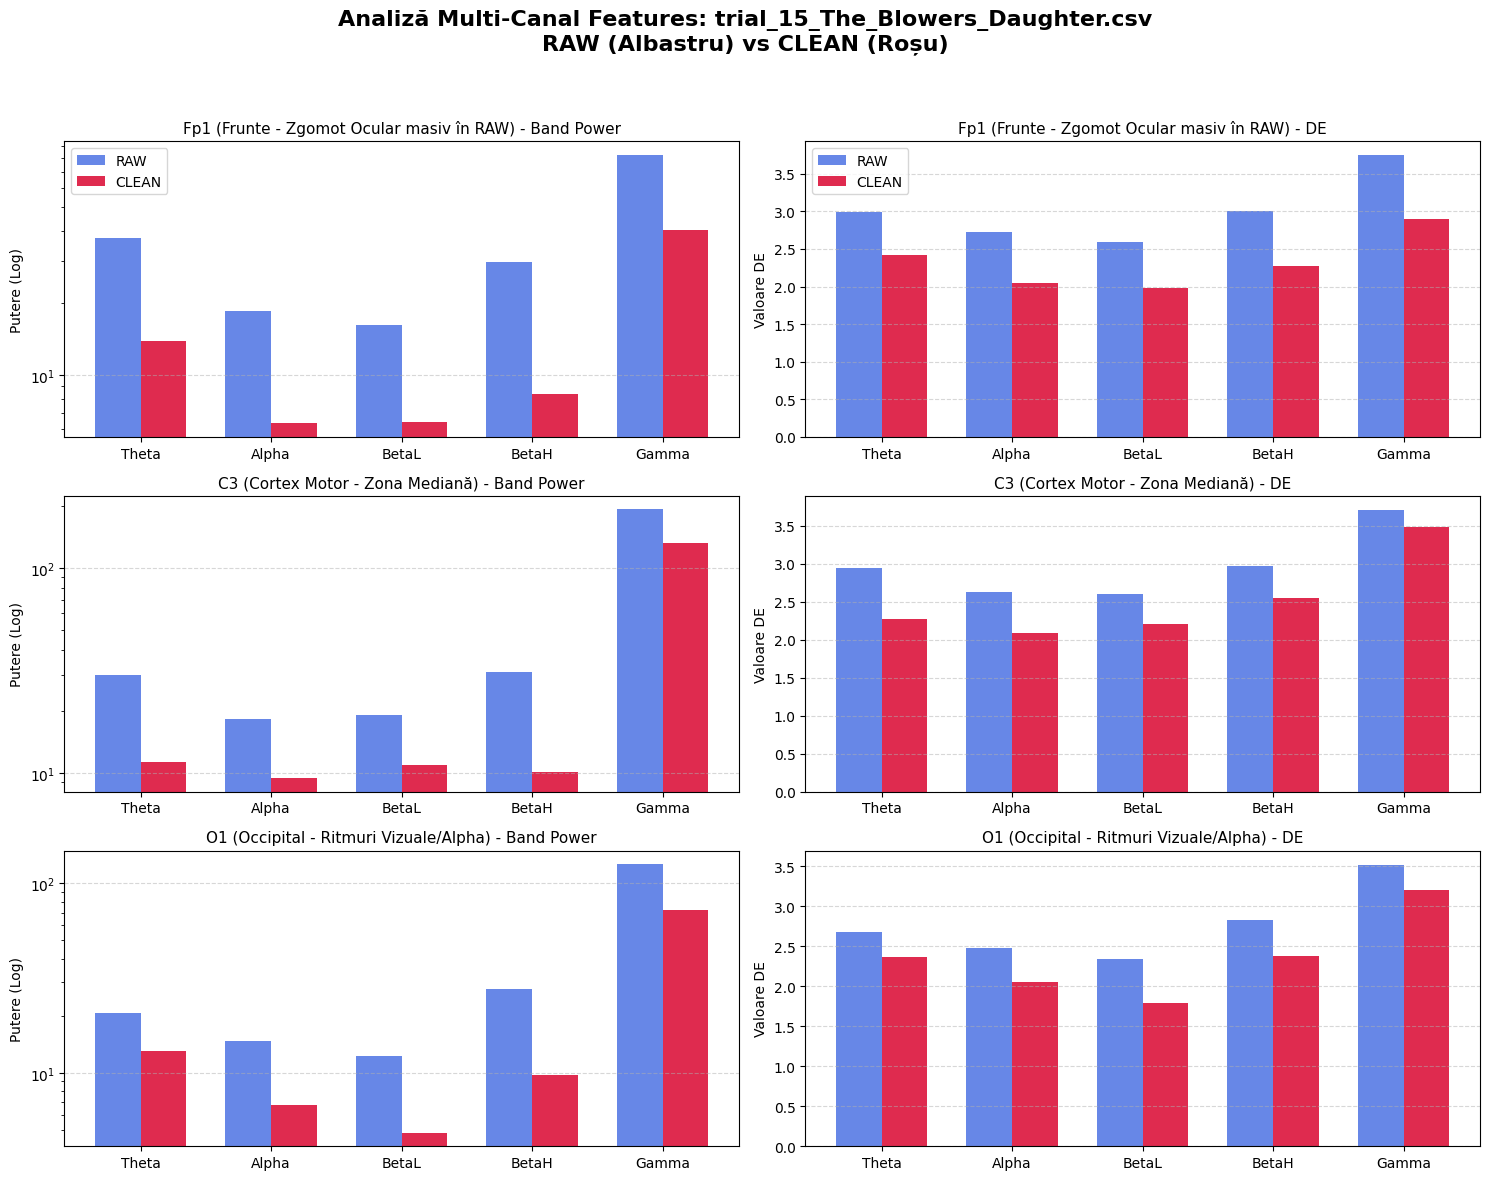

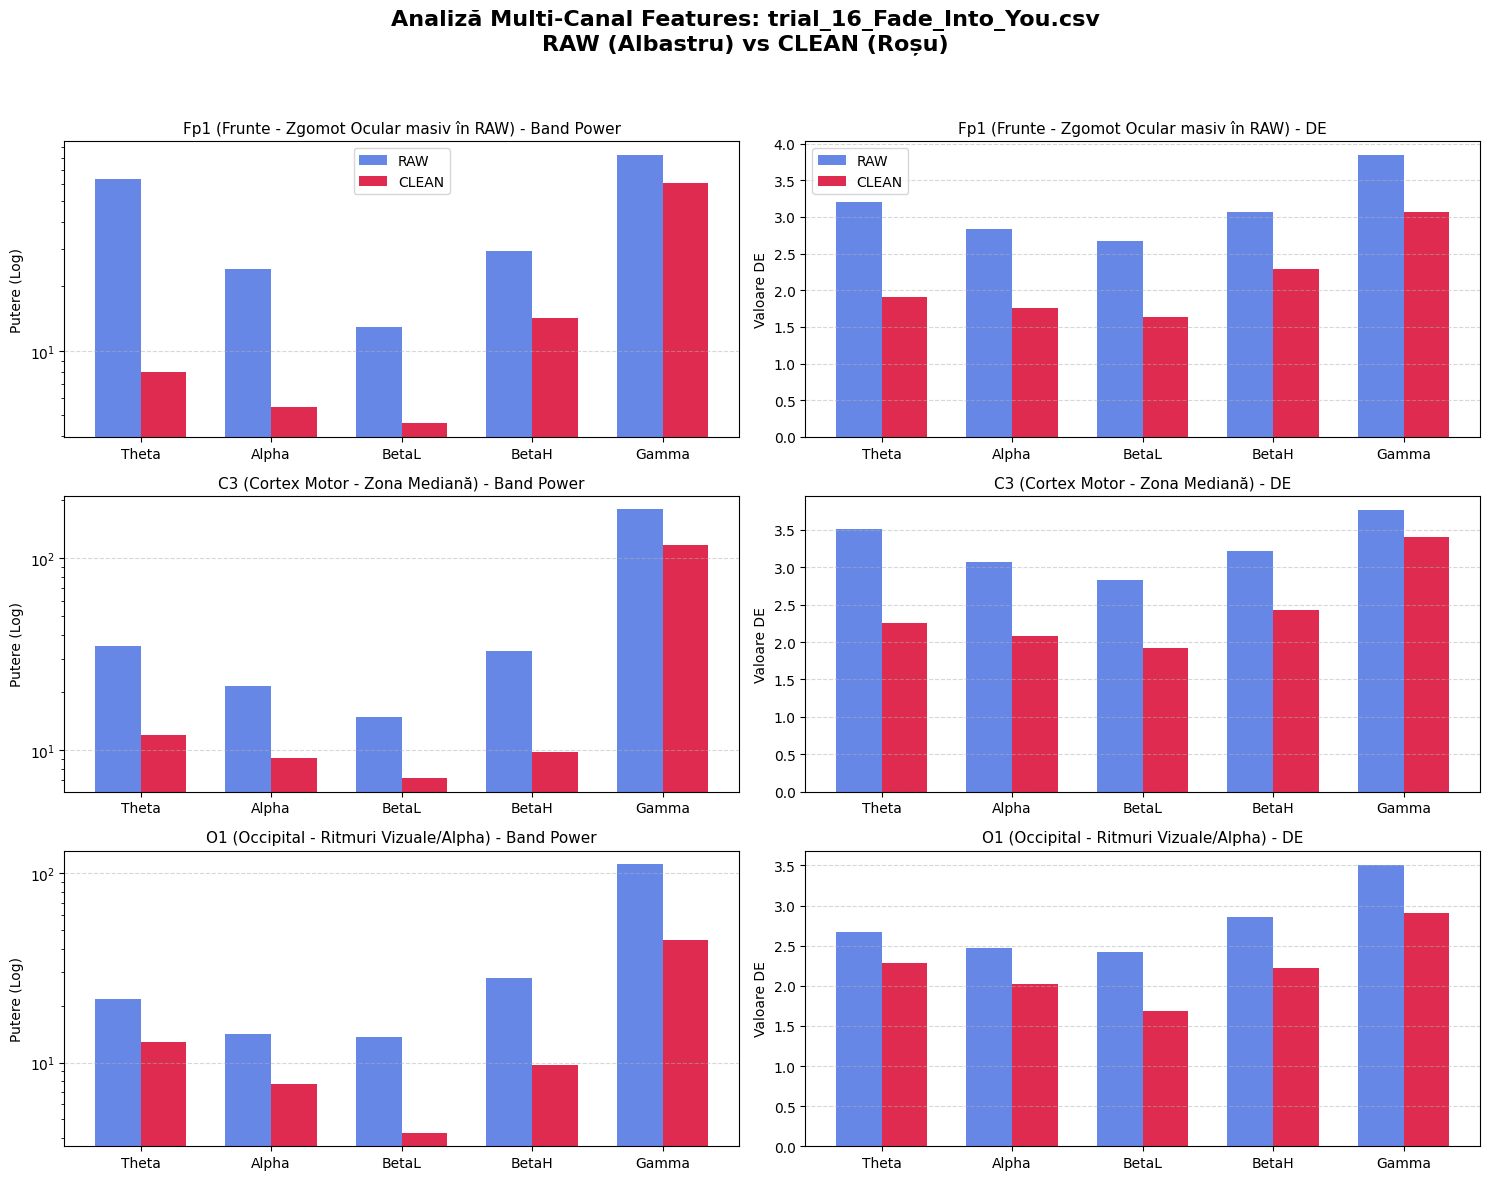

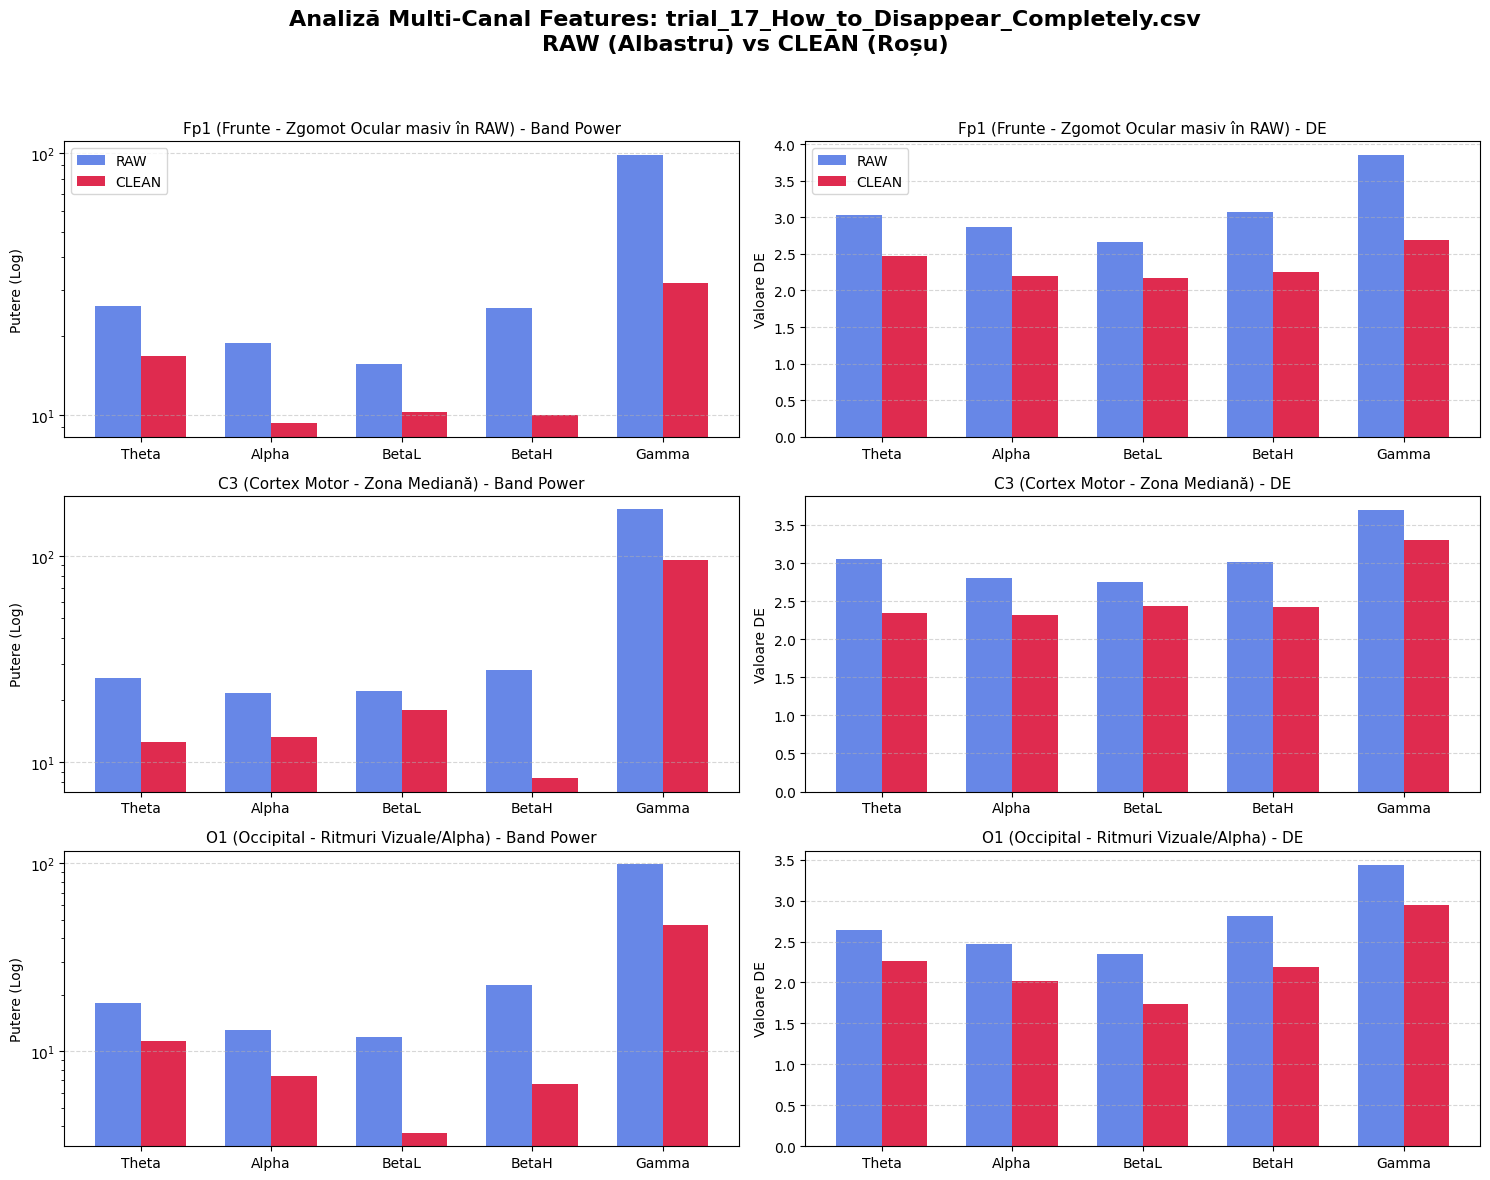

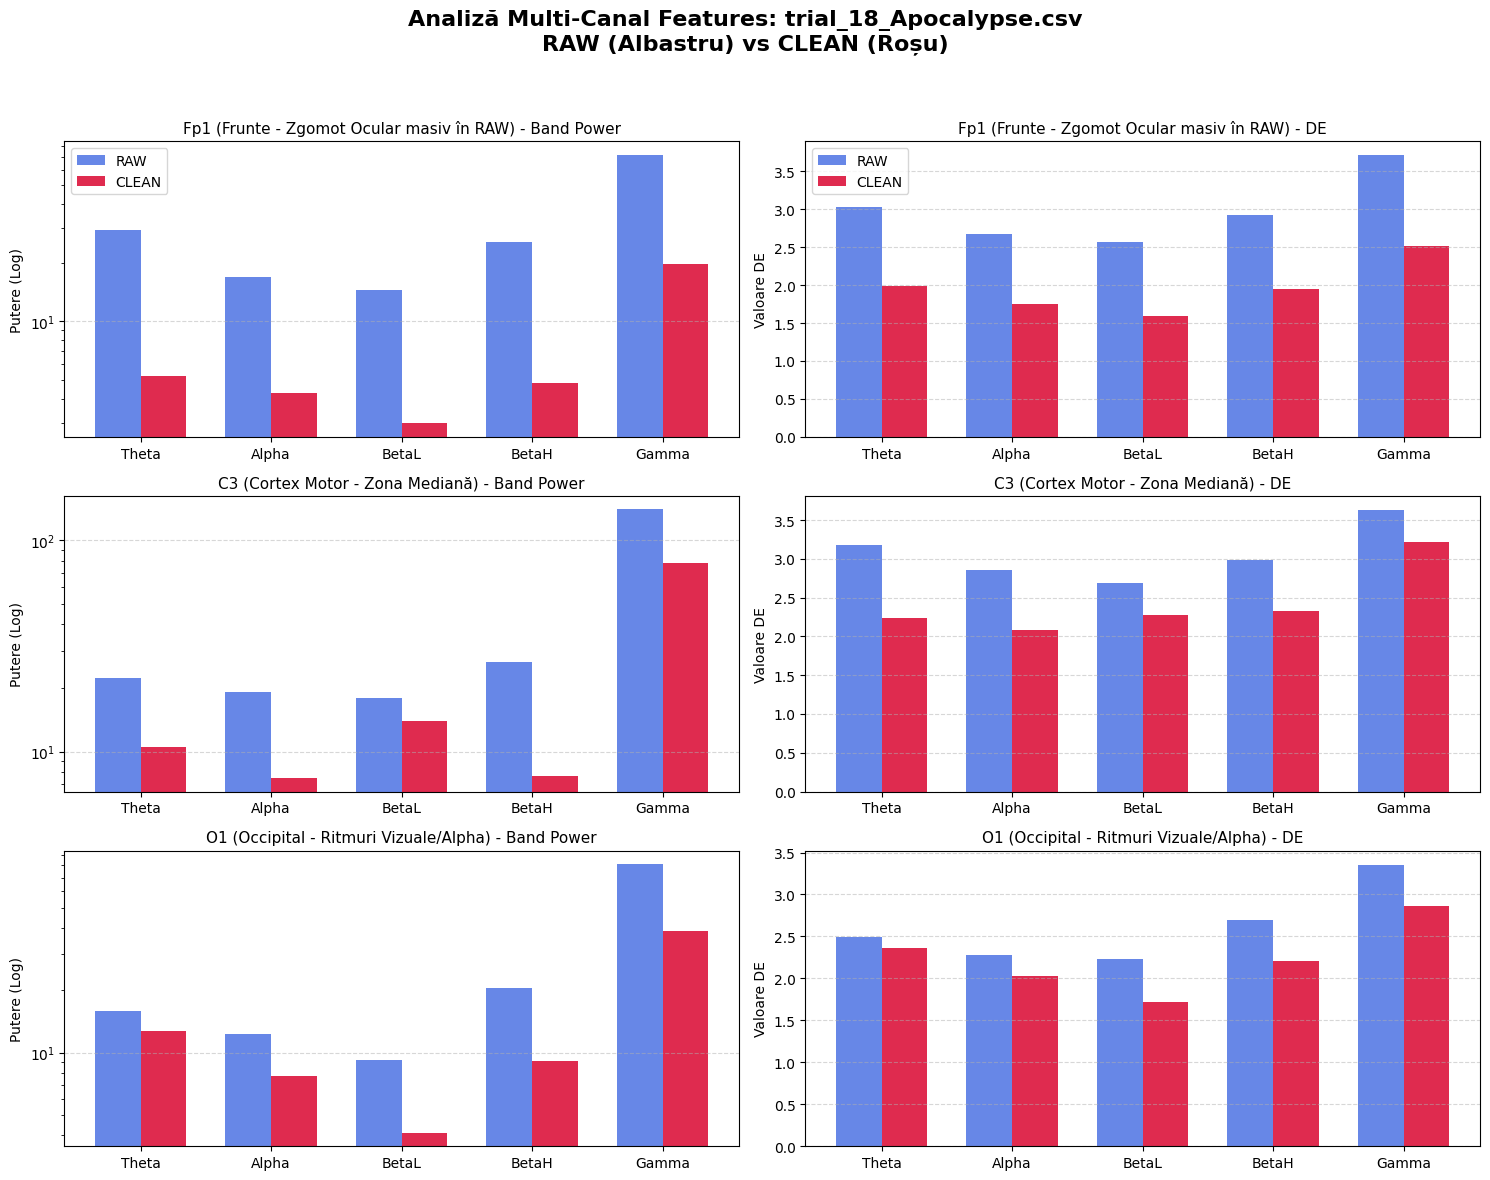

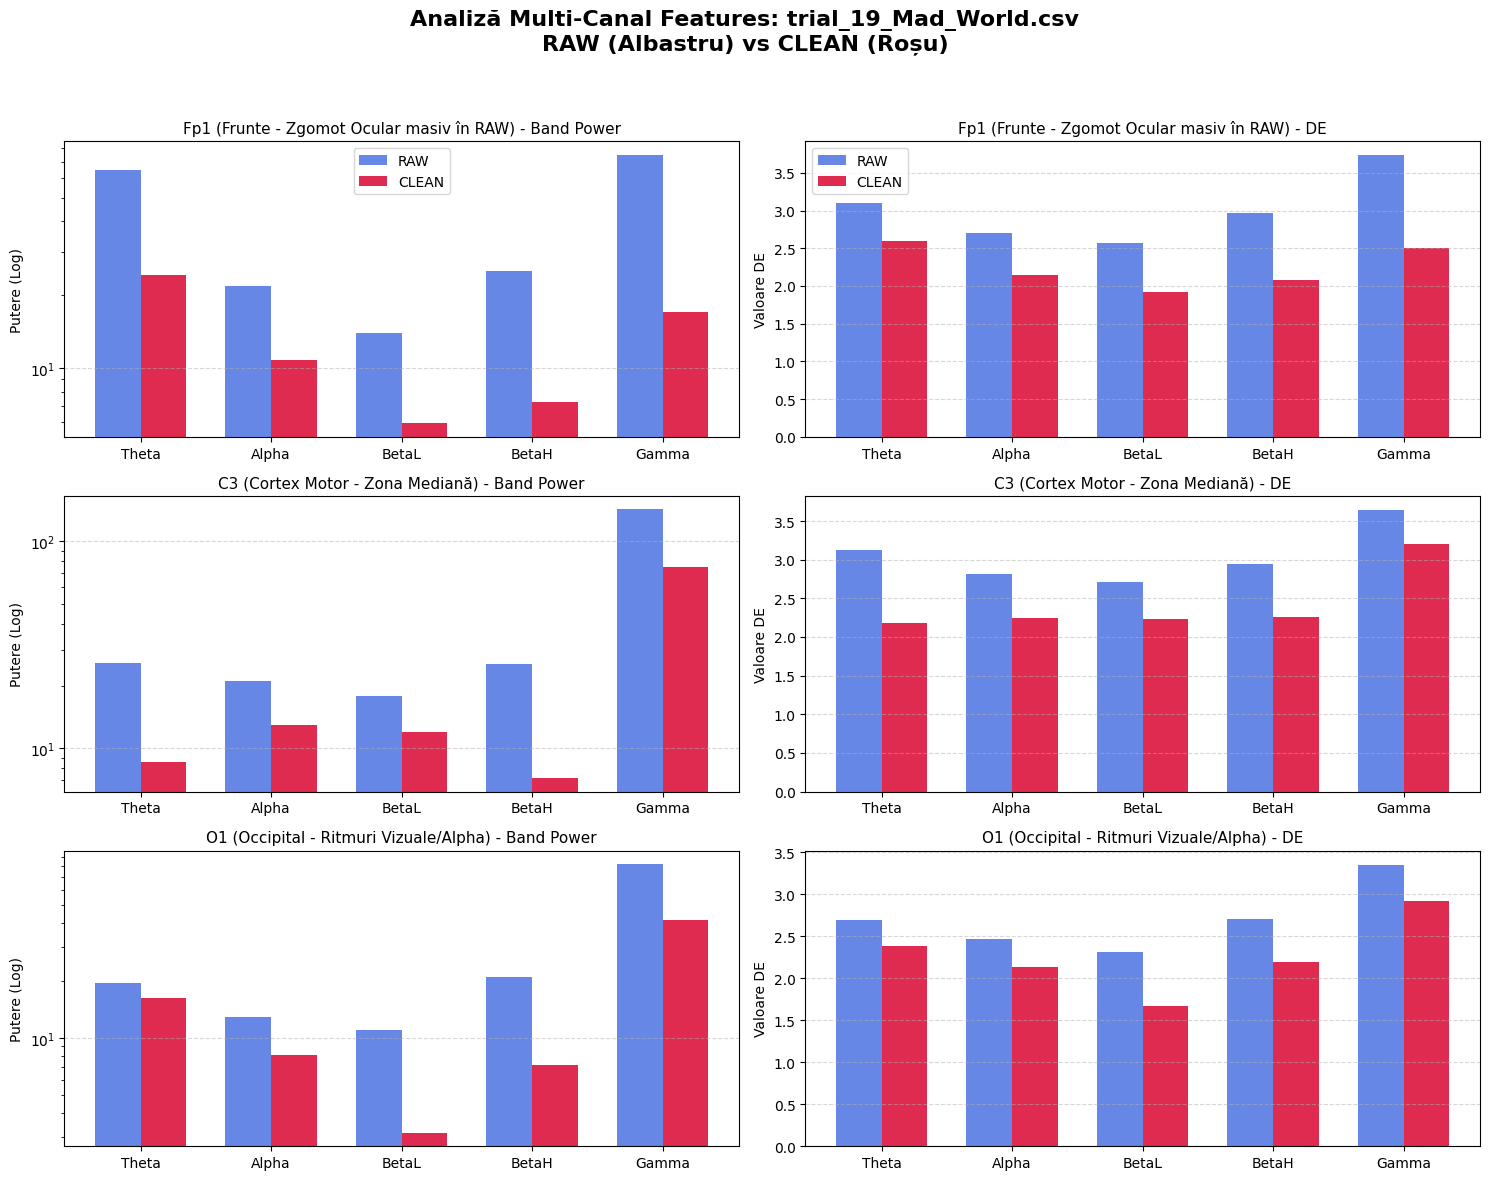

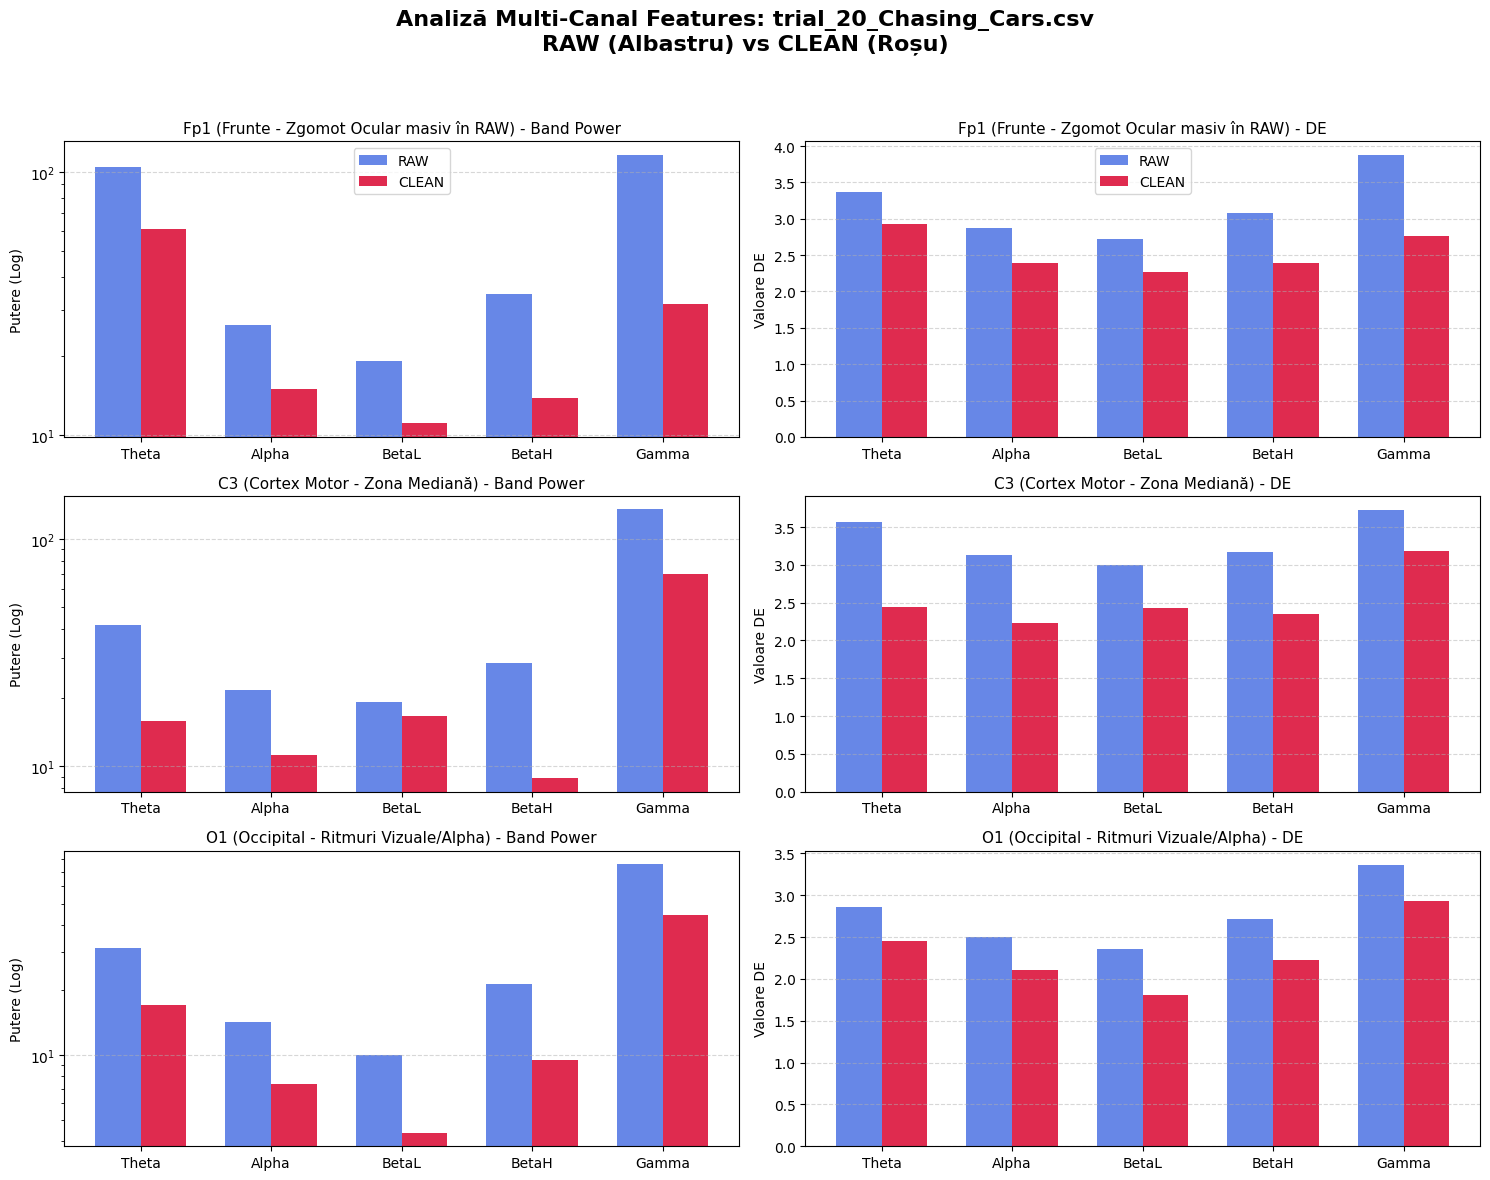

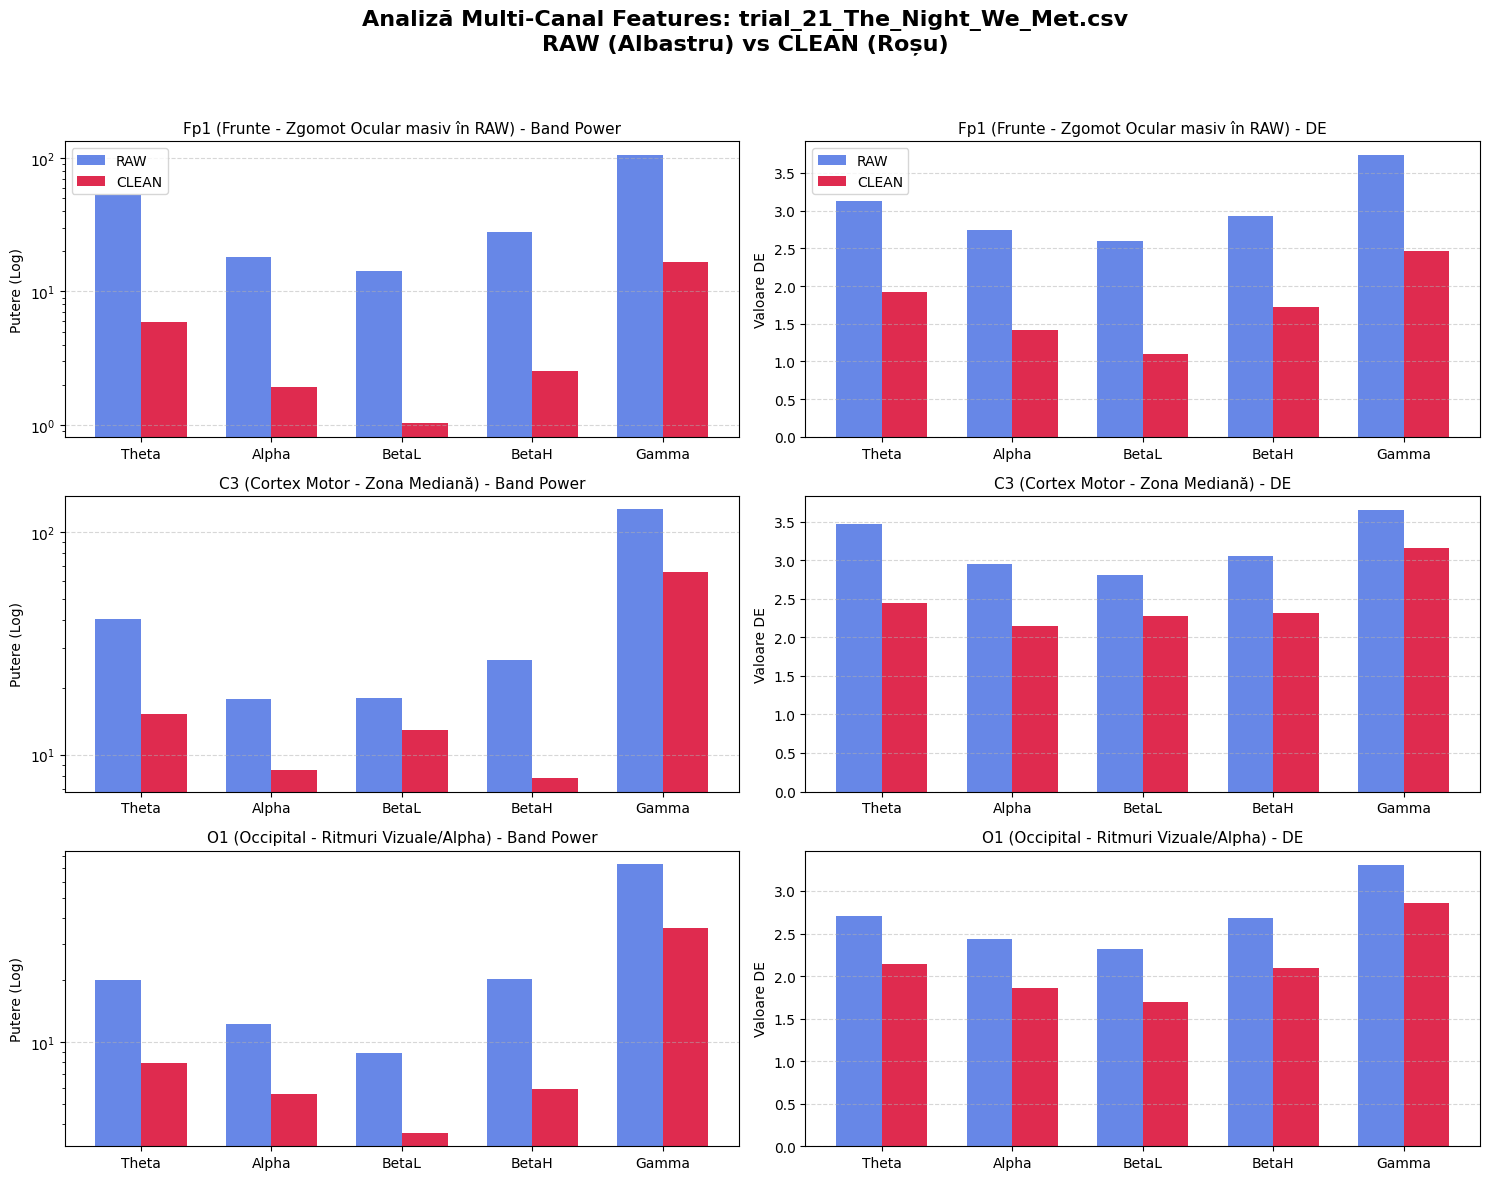

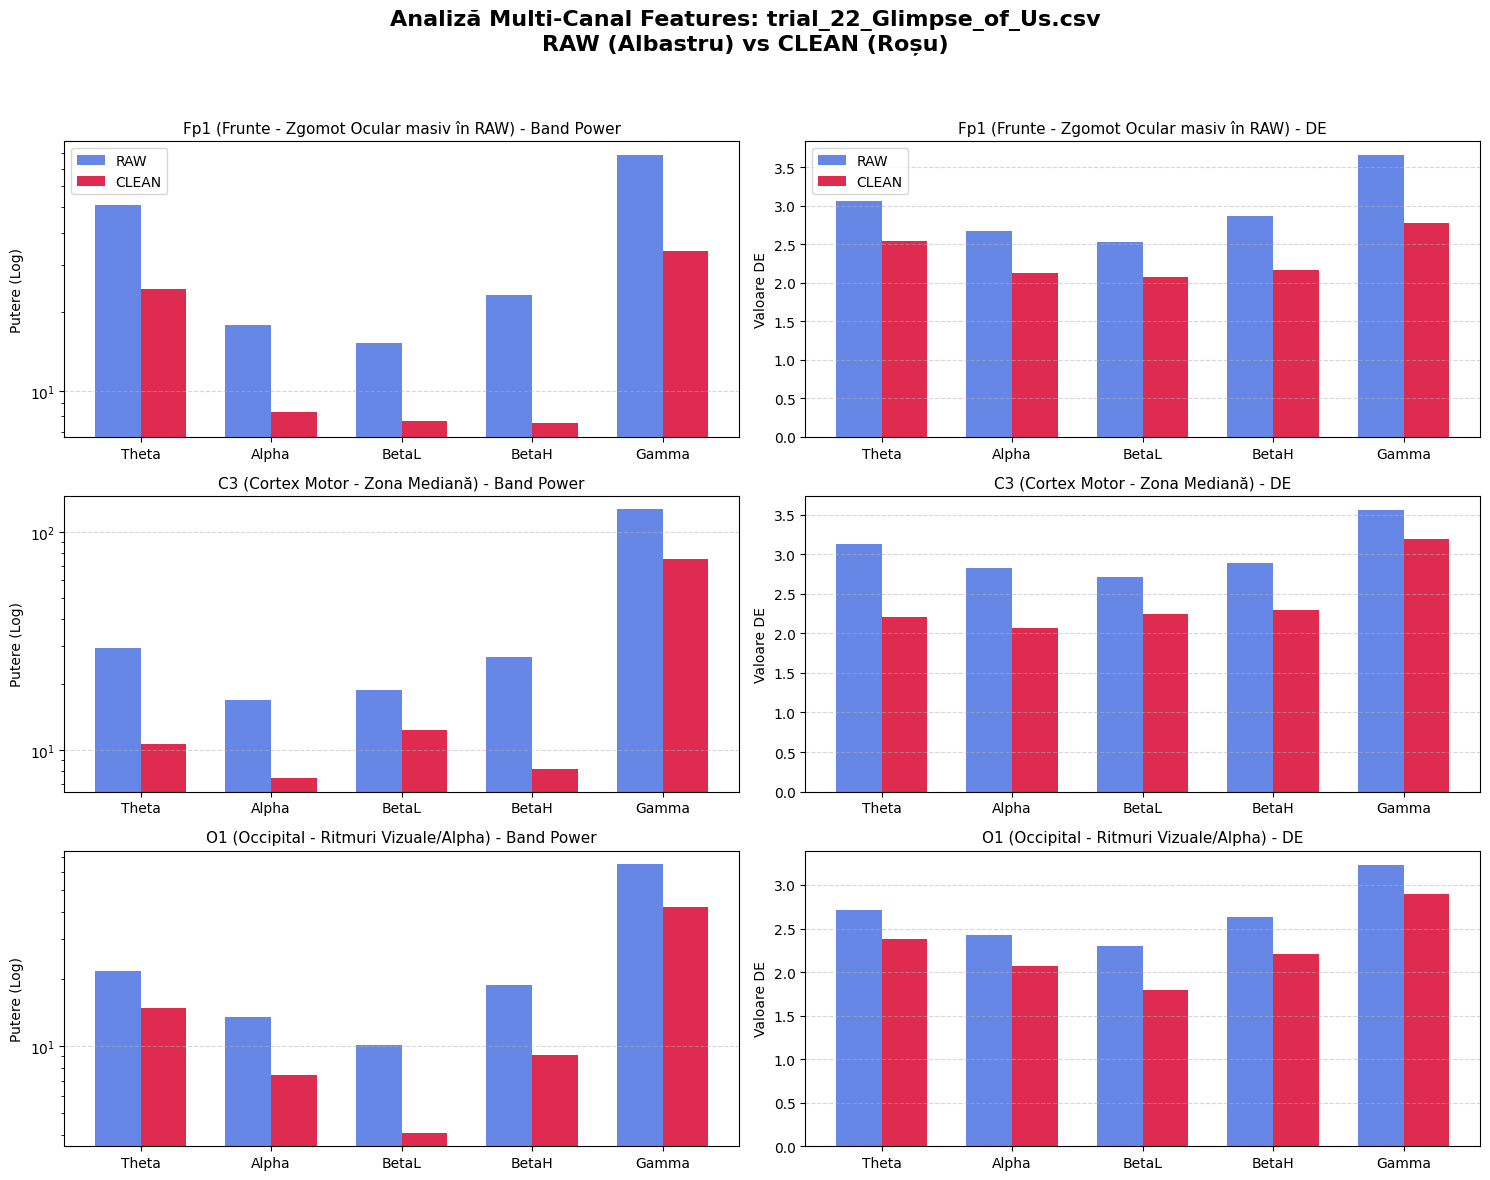

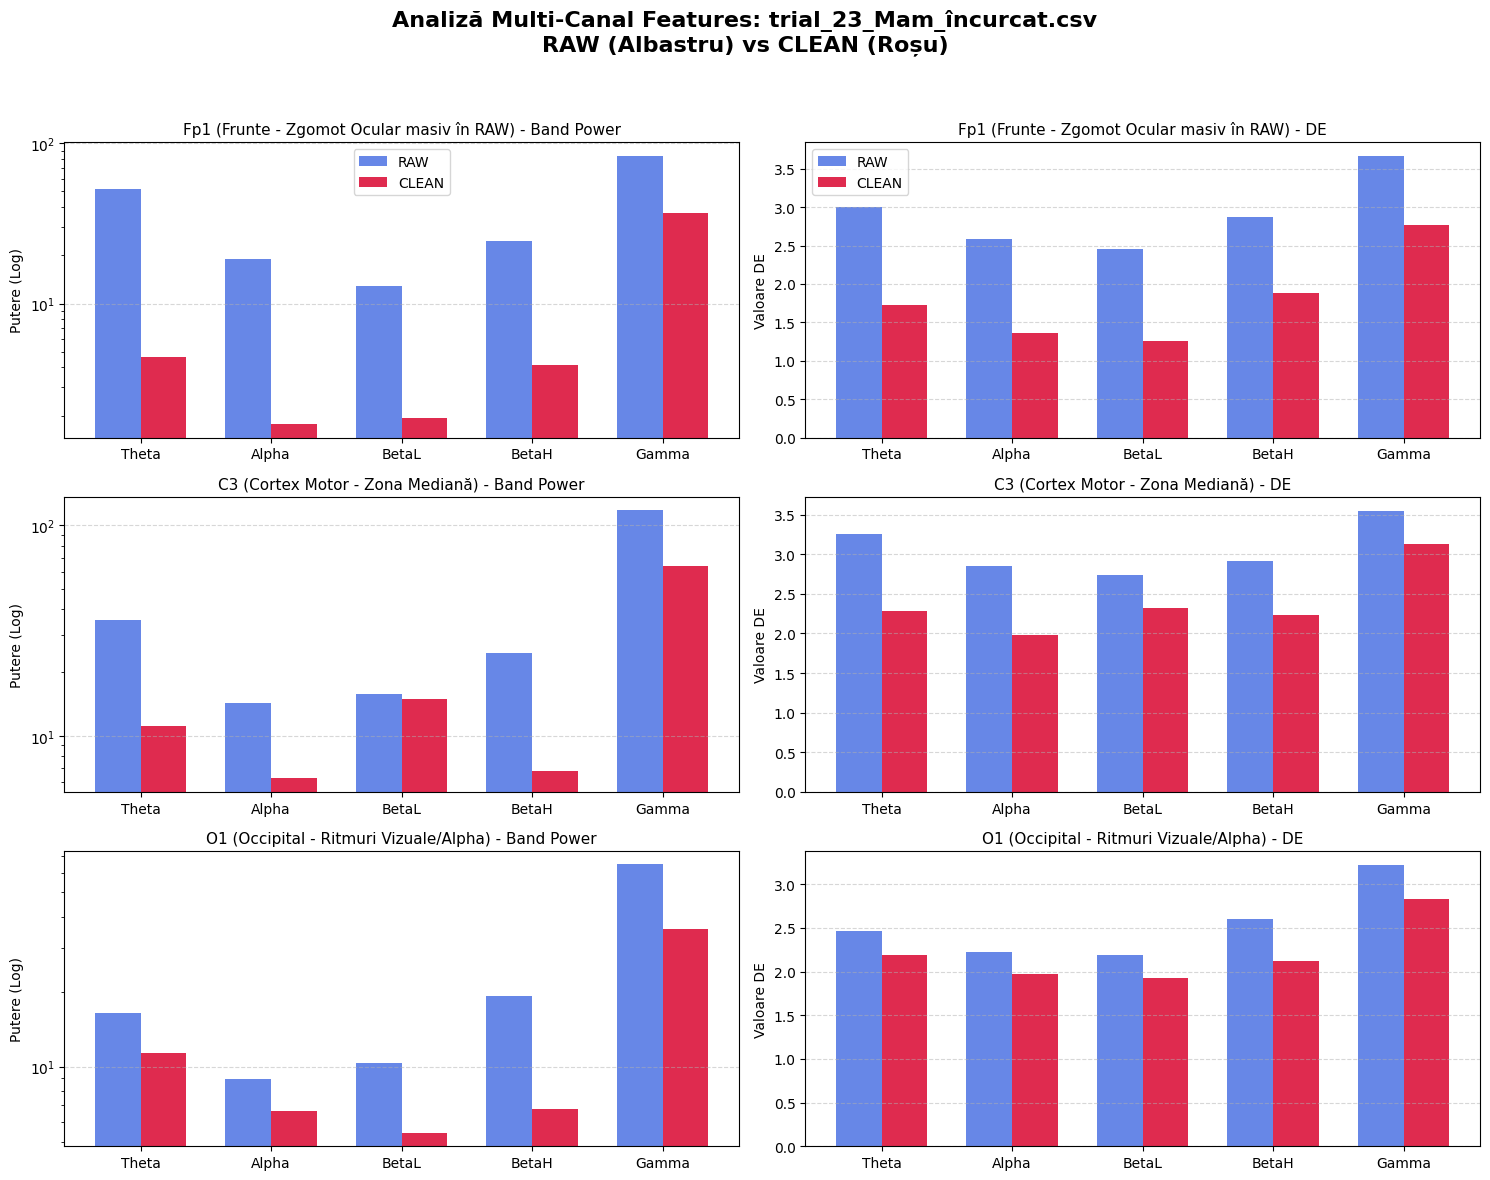

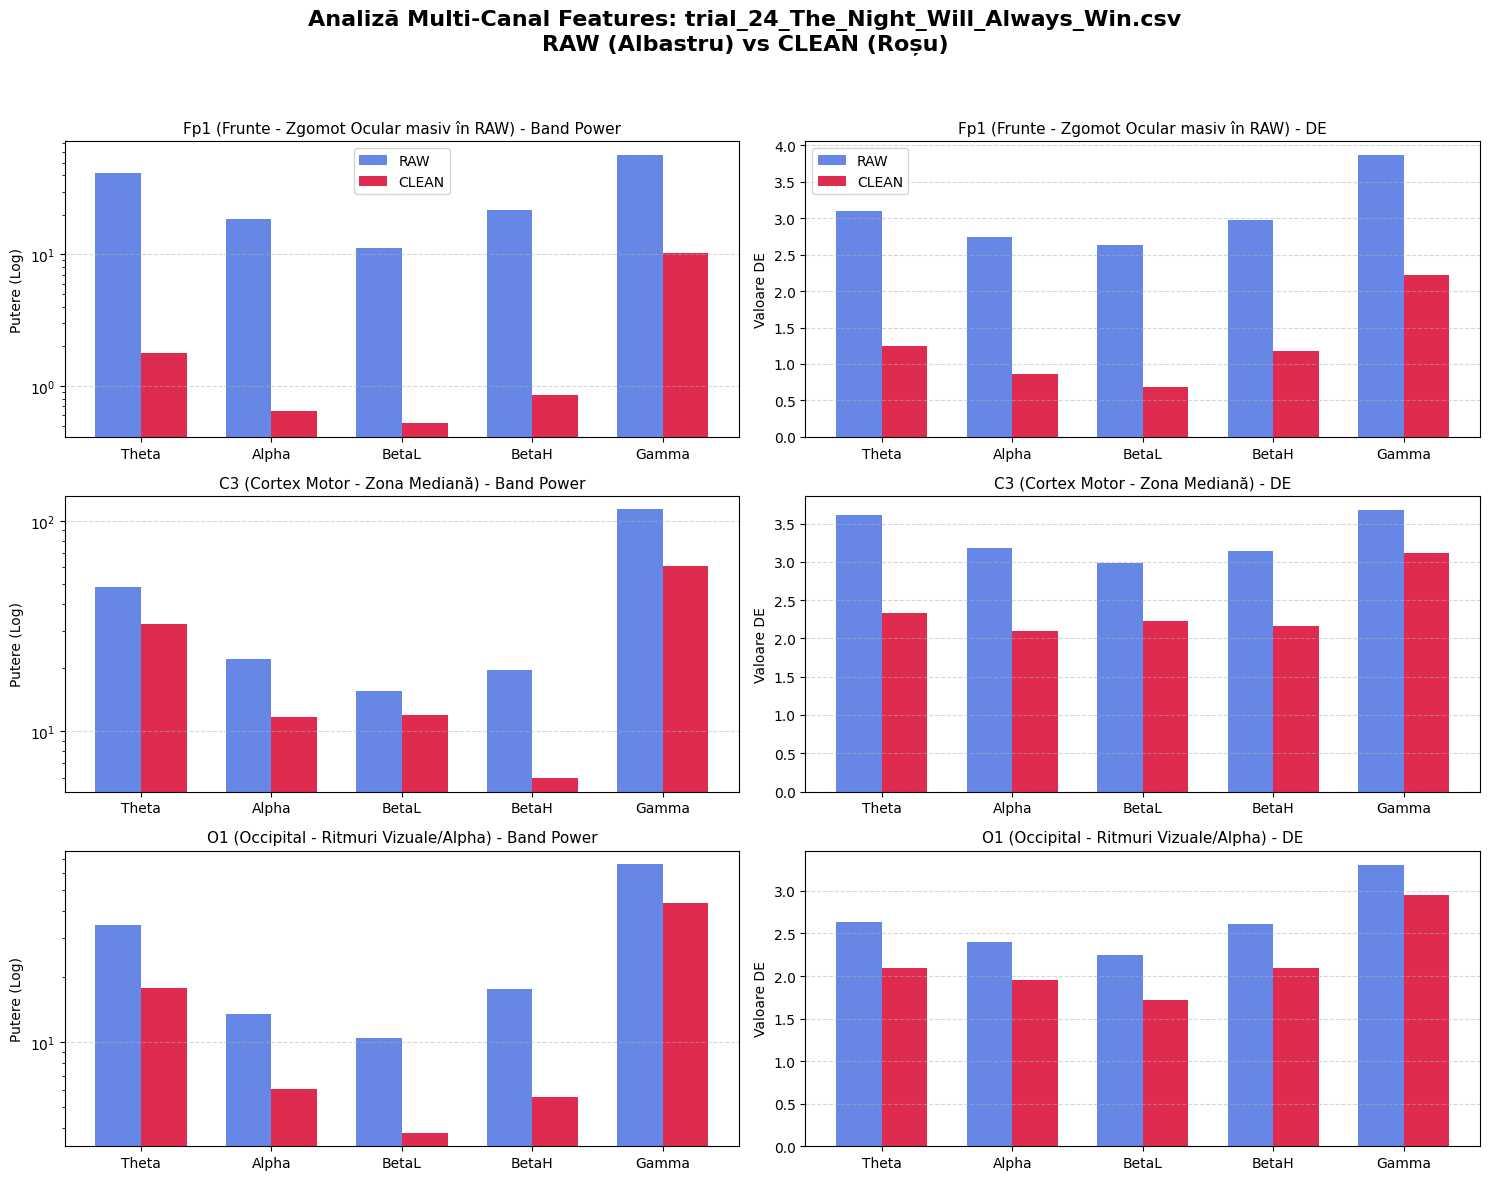

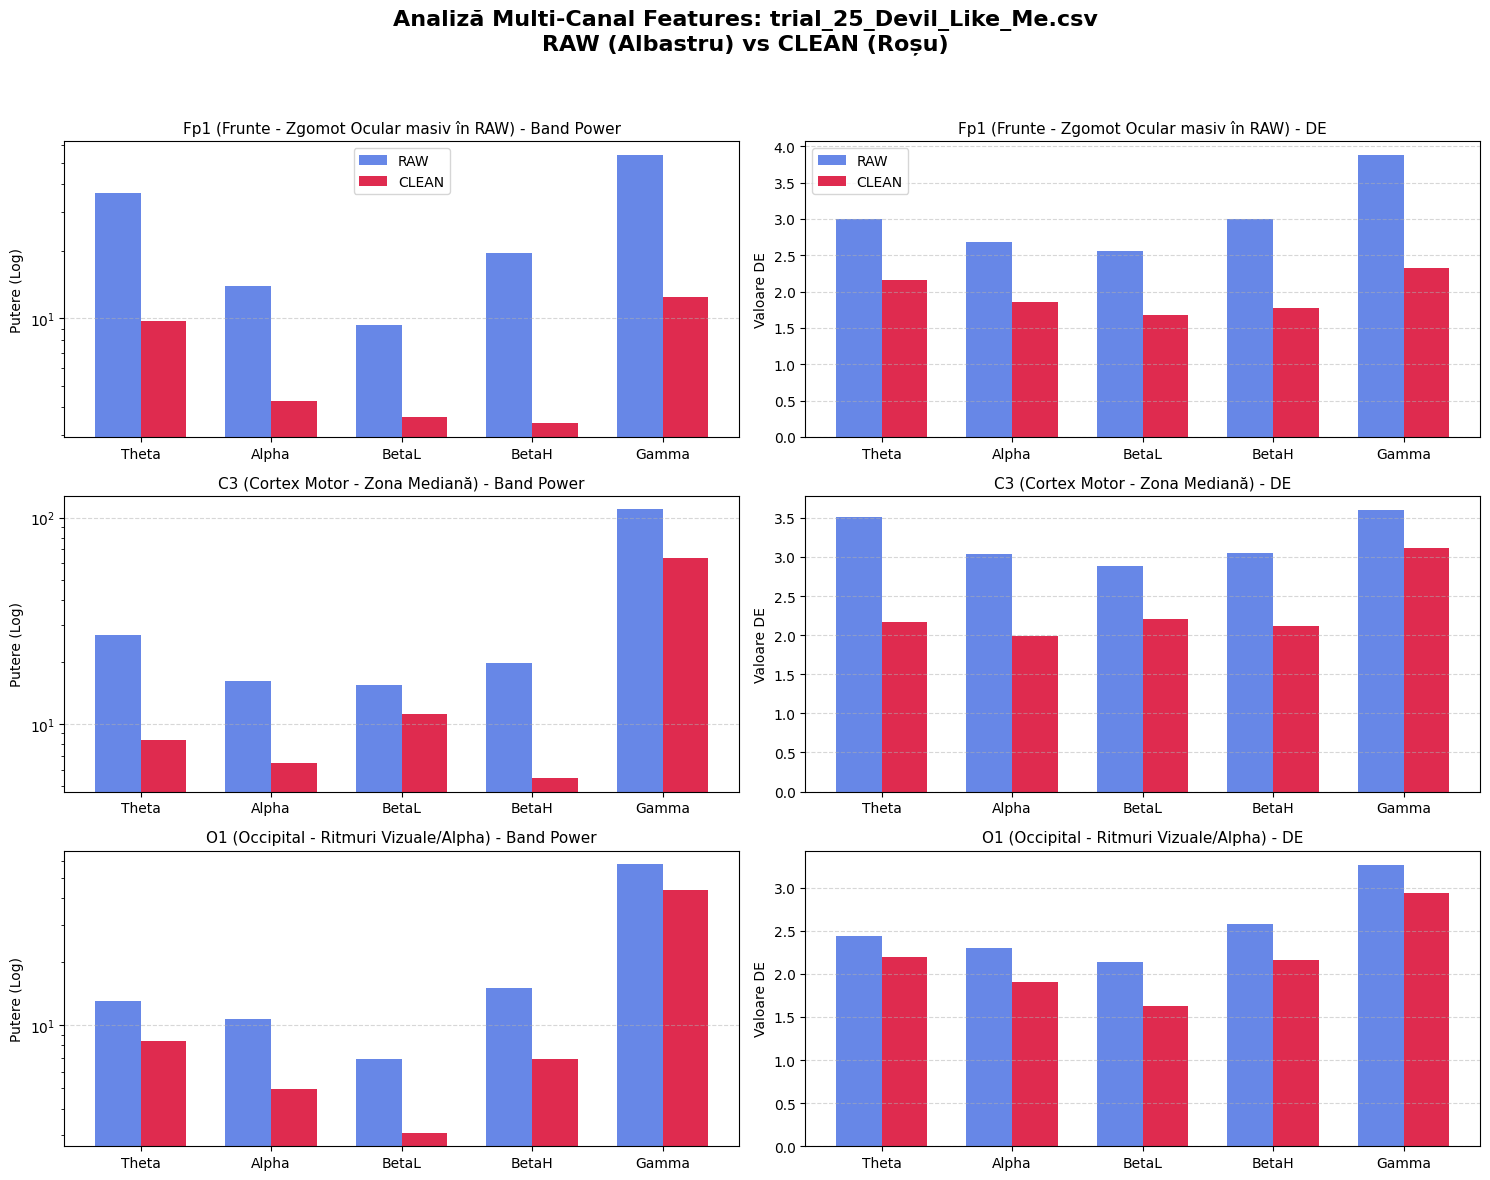

In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import warnings

warnings.filterwarnings('ignore')

# ── Configurare ────────────────────────────────────────────────────────────
DIR_RAW = "recordings_sad"
DIR_CLEAN = "recordings_sad_cleaned"
SFREQ = 125.0

BANDS = [4, 8, 12, 16, 25, 45]
BAND_LABELS = ["Theta", "Alpha", "BetaL", "BetaH", "Gamma"]

# Definim cele 3 canale cheie pentru a avea un "tablou" complet al capului
CHANNELS_TO_PLOT = [
    {"raw": "EEG_1", "clean": "Fp1", "title": "Fp1 (Frunte - Zgomot Ocular masiv în RAW)"},
    {"raw": "EEG_3", "clean": "C3",  "title": "C3 (Cortex Motor - Zona Mediană)"},
    {"raw": "EEG_7", "clean": "O1",  "title": "O1 (Occipital - Ritmuri Vizuale/Alpha)"}
]

def extract_trial_number(filepath: str) -> int:
    match = re.search(r'trial_(\d+)_', os.path.basename(filepath))
    return int(match.group(1)) if match else 999

def calculate_de(sig, band_edges, fs):
    de = []
    fft_full = np.fft.rfft(sig)
    freqs = np.fft.rfftfreq(len(sig), 1.0 / fs)
    for lo, hi in zip(band_edges[:-1], band_edges[1:]):
        mask = (freqs >= lo) & (freqs < hi)
        f = np.zeros_like(fft_full)
        f[mask] = fft_full[mask]
        var = np.var(np.fft.irfft(f, n=len(sig))) + 1e-10
        de.append(0.5 * np.log(2 * np.pi * np.e * var))
    return np.array(de)

def calculate_bp(sig, band_edges, fs):
    freqs, psd = welch(sig, fs, nperseg=len(sig))
    bp = []
    for lo, hi in zip(band_edges[:-1], band_edges[1:]):
        idx = np.logical_and(freqs >= lo, freqs < hi)
        bp.append(np.sum(psd[idx]))
    return np.array(bp)

def get_trial_features(signal, fs, window_sec=2.0):
    window_samples = int(fs * window_sec)
    all_bp, all_de = [], []
    for start in range(0, len(signal) - window_samples, window_samples):
        window = signal[start : start + window_samples]
        all_bp.append(calculate_bp(window, BANDS, fs))
        all_de.append(calculate_de(window, BANDS, fs))
    return np.mean(all_bp, axis=0), np.mean(all_de, axis=0)

def main():
    raw_files = glob.glob(os.path.join(DIR_RAW, "*.csv"))
    raw_files = sorted(raw_files, key=extract_trial_number)

    if not raw_files:
        print(f"Eroare: Nu am găsit fișiere în {DIR_RAW}")
        return

    print("Extrag trăsăturile. Închide fereastra graficului pentru a trece la următorul trial.")

    for raw_path in raw_files:
        filename = os.path.basename(raw_path)
        clean_path = os.path.join(DIR_CLEAN, f"clean_{filename}")
        
        if not os.path.exists(clean_path):
            continue
            
        df_raw = pd.read_csv(raw_path)
        df_clean = pd.read_csv(clean_path)
        
        # Creăm o figură mare cu 3 rânduri (canale) și 2 coloane (BP și DE)
        fig, axes = plt.subplots(len(CHANNELS_TO_PLOT), 2, figsize=(15, 12))
        fig.suptitle(f"Analiză Multi-Canal Features: {filename}\nRAW (Albastru) vs CLEAN (Roșu)", fontsize=16, fontweight='bold', y=0.98)
        
        x = np.arange(len(BAND_LABELS))
        width = 0.35  
        
        for row_idx, ch_info in enumerate(CHANNELS_TO_PLOT):
            sig_raw = df_raw[ch_info['raw']].values
            sig_clean = df_clean[ch_info['clean']].values
            
            bp_raw, de_raw = get_trial_features(sig_raw, SFREQ)
            bp_clean, de_clean = get_trial_features(sig_clean, SFREQ)
            
            ax_bp = axes[row_idx, 0]
            ax_de = axes[row_idx, 1]
            
            # --- Graficul Band Power (Stânga) ---
            ax_bp.bar(x - width/2, bp_raw, width, label='RAW', color='royalblue', alpha=0.8)
            ax_bp.bar(x + width/2, bp_clean, width, label='CLEAN', color='crimson', alpha=0.9)
            ax_bp.set_title(f"{ch_info['title']} - Band Power", fontsize=11)
            ax_bp.set_ylabel('Putere (Log)')
            ax_bp.set_xticks(x)
            ax_bp.set_xticklabels(BAND_LABELS)
            ax_bp.set_yscale('log')
            if row_idx == 0: ax_bp.legend()
            ax_bp.grid(True, axis='y', linestyle='--', alpha=0.5)
            
            # --- Graficul Differential Entropy (Dreapta) ---
            ax_de.bar(x - width/2, de_raw, width, label='RAW', color='royalblue', alpha=0.8)
            ax_de.bar(x + width/2, de_clean, width, label='CLEAN', color='crimson', alpha=0.9)
            ax_de.set_title(f"{ch_info['title']} - DE", fontsize=11)
            ax_de.set_ylabel('Valoare DE')
            ax_de.set_xticks(x)
            ax_de.set_xticklabels(BAND_LABELS)
            if row_idx == 0: ax_de.legend()
            ax_de.grid(True, axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout(rect=[0, 0, 1, 0.95]) # Lasă spațiu pentru titlul principal
        plt.show()

if __name__ == "__main__":
    main()